In [1]:
# ========================================
# CELL 1: VERIFIKASI STRUKTUR DATASET
# ========================================
"""
JALANKAN CELL INI PERTAMA!
Verifikasi struktur folder dataset Kaggle sebelum training.
Dataset harus sudah ditambahkan via: Add Data → Your Datasets → crisismmd
"""

import os
from pathlib import Path

# ── Kaggle dataset root ──────────────────────────────────────────────────────
# Kaggle otomatis mount dataset di /kaggle/input/{dataset-slug}/
# Ganti 'crisismmd' jika slug dataset Anda berbeda (cek di URL dataset Anda)
KAGGLE_INPUT = '/kaggle/input/datasets/alieffathurrahman/crisismmd'

print("=" * 60)
print("DATASET STRUCTURE VERIFICATION")
print("=" * 60)

# 1. Cek root dataset ada
if not os.path.exists(KAGGLE_INPUT):
    raise FileNotFoundError(
        f"\n❌ Dataset tidak ditemukan di: {KAGGLE_INPUT}\n"
        "Pastikan:\n"
        "  1. Dataset sudah diupload ke Kaggle (My Datasets → crisismmd)\n"
        "  2. Dataset sudah ditambahkan ke notebook: Add Data → Your Datasets\n"
        "  3. Slug dataset sesuai — cek URL: kaggle.com/datasets/<username>/crisismmd\n"
        "     Jika slug berbeda, ubah variable KAGGLE_INPUT di atas."
    )

print(f"✅ Root dataset ditemukan: {KAGGLE_INPUT}")

# 2. List semua isi root
print(f"\n📁 Isi root ({KAGGLE_INPUT}):")
for item in sorted(os.listdir(KAGGLE_INPUT)):
    full = os.path.join(KAGGLE_INPUT, item)
    kind = "📂" if os.path.isdir(full) else "📄"
    print(f"   {kind} {item}")

# 3. Cari folder CrisisMMD_v2.0 (bisa langsung di root atau di subfolder)
def find_dir(root, target):
    """Cari folder target secara rekursif."""
    for dirpath, dirnames, _ in os.walk(root):
        if target in dirnames:
            return os.path.join(dirpath, target)
    return None

CRISISMMMD_ROOT = None
# Coba langsung
if os.path.isdir(os.path.join(KAGGLE_INPUT, 'CrisisMMD_v2.0')):
    CRISISMMMD_ROOT = os.path.join(KAGGLE_INPUT, 'CrisisMMD_v2.0')
else:
    CRISISMMMD_ROOT = find_dir(KAGGLE_INPUT, 'CrisisMMD_v2.0')

if CRISISMMMD_ROOT is None:
    # Mungkin tidak ada subfolder, dataset langsung di root
    # Cek apakah folder data_image, annotations, crisismmd_datasplit_all ada di root
    candidate_dirs = ['data_image', 'annotations', 'crisismmd_datasplit_all']
    if all(os.path.isdir(os.path.join(KAGGLE_INPUT, d)) for d in candidate_dirs):
        CRISISMMMD_ROOT = KAGGLE_INPUT
        print(f"\n✅ Struktur dataset langsung di root (tanpa subfolder CrisisMMD_v2.0)")
    else:
        print(f"\n⚠️  Folder 'CrisisMMD_v2.0' tidak ditemukan.")
        print("    Folder yang tersedia di root:")
        for d in os.listdir(KAGGLE_INPUT):
            print(f"      - {d}")
        raise FileNotFoundError(
            "❌ Tidak dapat menemukan struktur CrisisMMD.\n"
            "   Pastikan zip dataset diekstrak dengan benar saat upload ke Kaggle."
        )

print(f"\n✅ CrisisMMD root: {CRISISMMMD_ROOT}")

# 4. Verifikasi sub-folder kunci
print("\n📁 Verifikasi sub-folder:")

DATA_IMAGE_PATH   = os.path.join(CRISISMMMD_ROOT, 'data_image')
ANNOTATIONS_PATH  = os.path.join(CRISISMMMD_ROOT, 'annotations')

# Datasplit bisa berada di nested folder
DATASPLIT_CANDIDATES = [
    os.path.join(CRISISMMMD_ROOT, 'crisismmd_datasplit_all', 'crisismmd_datasplit_all'),
    os.path.join(CRISISMMMD_ROOT, 'crisismmd_datasplit_all'),
]
DATASPLIT_PATH = None
for c in DATASPLIT_CANDIDATES:
    if os.path.isdir(c):
        tsv_files = [f for f in os.listdir(c) if f.endswith('.tsv')]
        if tsv_files:
            DATASPLIT_PATH = c
            break

for label, path in [
    ('data_image',   DATA_IMAGE_PATH),
    ('annotations',  ANNOTATIONS_PATH),
    ('datasplit',    DATASPLIT_PATH),
]:
    exists = path is not None and os.path.isdir(path)
    icon = "✅" if exists else "❌"
    print(f"   {icon} {label}: {path}")

if not all([
    os.path.isdir(DATA_IMAGE_PATH),
    os.path.isdir(ANNOTATIONS_PATH),
    DATASPLIT_PATH is not None,
]):
    raise FileNotFoundError("❌ Satu atau lebih sub-folder kritis tidak ditemukan. Cek struktur zip dataset.")

# 5. Preview isi tiap folder
print(f"\n📁 data_image — subfolder (maks 5):")
print(f"   {sorted(os.listdir(DATA_IMAGE_PATH))[:5]} ...")

print(f"\n📄 annotations — file TSV (maks 5):")
ann_files = [f for f in sorted(os.listdir(ANNOTATIONS_PATH)) if f.endswith('.tsv')]
print(f"   {ann_files[:5]} ...")
print(f"   Total TSV: {len(ann_files)}")

print(f"\n📄 datasplit — file TSV:")
split_files = sorted([f for f in os.listdir(DATASPLIT_PATH) if f.endswith('.tsv')])
for f in split_files:
    print(f"   - {f}")

# 6. Cek file datasplit wajib ada
REQUIRED_SPLITS = [
    'task_informative_text_img_train.tsv',
    'task_informative_text_img_dev.tsv',
    'task_informative_text_img_test.tsv',
    'task_humanitarian_text_img_train.tsv',
    'task_humanitarian_text_img_dev.tsv',
    'task_humanitarian_text_img_test.tsv',
]
print("\n📄 Verifikasi file datasplit wajib:")
missing = []
for req in REQUIRED_SPLITS:
    exists = req in split_files
    icon = "✅" if exists else "❌"
    print(f"   {icon} {req}")
    if not exists:
        missing.append(req)

if missing:
    print(f"\n⚠️  {len(missing)} file datasplit tidak ditemukan.")
    print("   Pastikan dataset lengkap sebelum lanjut training.")
else:
    print("\n✅ Semua file datasplit tersedia!")

# 7. Quick sanity check: baca satu file annotations
import pandas as pd
sample_ann = ann_files[0]
try:
    df_sample = pd.read_csv(os.path.join(ANNOTATIONS_PATH, sample_ann), sep='\t', encoding='latin-1')
    print(f"\n📊 Preview annotations ({sample_ann}):")
    print(f"   Shape: {df_sample.shape}")
    print(f"   Columns: {df_sample.columns.tolist()}")
    print(f"   Sample rows:")
    print(df_sample.head(2).to_string(index=False))
except Exception as e:
    print(f"\n⚠️  Gagal membaca file annotations: {e}")

print("\n" + "=" * 60)
print("✅ VERIFIKASI SELESAI — Aman lanjut ke Cell berikutnya!")
print("=" * 60)
print(f"\nPath yang akan digunakan:")
print(f"  BASE_PATH       = {CRISISMMMD_ROOT}")
print(f"  DATA_IMAGE_PATH = {DATA_IMAGE_PATH}")
print(f"  ANNOTATIONS_PATH= {ANNOTATIONS_PATH}")
print(f"  DATASPLIT_PATH  = {DATASPLIT_PATH}")

DATASET STRUCTURE VERIFICATION
✅ Root dataset ditemukan: /kaggle/input/datasets/alieffathurrahman/crisismmd

📁 Isi root (/kaggle/input/datasets/alieffathurrahman/crisismmd):
   📂 annotations
   📂 crisismmd_datasplit_all
   📂 data_image

✅ Struktur dataset langsung di root (tanpa subfolder CrisisMMD_v2.0)

✅ CrisisMMD root: /kaggle/input/datasets/alieffathurrahman/crisismmd

📁 Verifikasi sub-folder:
   ✅ data_image: /kaggle/input/datasets/alieffathurrahman/crisismmd/data_image
   ✅ annotations: /kaggle/input/datasets/alieffathurrahman/crisismmd/annotations
   ✅ datasplit: /kaggle/input/datasets/alieffathurrahman/crisismmd/crisismmd_datasplit_all/crisismmd_datasplit_all

📁 data_image — subfolder (maks 5):
   ['california_wildfires', 'hurricane_harvey', 'hurricane_irma', 'hurricane_maria', 'iraq_iran_earthquake'] ...

📄 annotations — file TSV (maks 5):
   ['._california_wildfires_final_data.tsv', '._hurricane_irma_final_data.tsv', '._hurricane_maria_final_data.tsv', '._srilanka_floods_fin

In [2]:
# ========================================
# CELL 2: Install Libraries
# ========================================
"""
Install library tambahan yang belum ada di Kaggle
"""

import subprocess
subprocess.run(['pip', 'install', '-q', 'timm', 'torchmetrics', 'thop'], check=True)


CompletedProcess(args=['pip', 'install', '-q', 'timm', 'torchmetrics', 'thop'], returncode=0)

In [3]:
# ========================================
# CELL 3: Import Libraries
# ========================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import timm
import pandas as pd
import numpy as np
from PIL import Image
from typing import Dict, List, Tuple, Optional
import time
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
import json
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Output dir (Kaggle working directory)
OUTPUT_DIR = '/kaggle/working'
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, 'checkpoints')
RESULTS_DIR    = os.path.join(OUTPUT_DIR, 'results')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"\nOutput directory: {OUTPUT_DIR}")

Using device: cuda
GPU: Tesla T4
Memory: 15.64 GB

Output directory: /kaggle/working


In [6]:
# ========================================
# CELL 4 (UPDATED): Configuration
# ========================================
"""
Tambahan config untuk ConvNeXt dan Swin
"""

SUBSET_SIZE = None
TASK        = 'informative'

BASE_PATH = CRISISMMMD_ROOT  # dari Cell 1

TASK_CONFIG = {
    'informative': {
        'num_classes': 2,
        'label_col': 'image_info',
        'class_names': ['not_informative', 'informative'],
        'label_map': {'not_informative': 0, 'informative': 1}
    },
    'humanitarian': {
        'num_classes': 7,
        'label_col': 'image_human',
        'class_names': [
            'infrastructure_and_utility_damage', 'affected_individuals',
            'injured_or_dead_people', 'missing_or_found_people',
            'rescue_volunteering_or_donation_effort', 'vehicle_damage',
            'other_relevant_information'
        ],
        'label_map': {
            'infrastructure_and_utility_damage': 0, 'affected_individuals': 1,
            'injured_or_dead_people': 2, 'missing_or_found_people': 3,
            'rescue_volunteering_or_donation_effort': 4, 'vehicle_damage': 5,
            'other_relevant_information': 6
        }
    }
}

# ── MODEL CONFIG (tambah convnext & swin) ────────────────────────────────────
MODEL_CONFIG = {
    'efficientnet': {
        'name': 'efficientnet_b0',
        'input_size': 224,
        'batch_size': 32,
        'lr': 1e-4
    },
    'vit': {
        'name': 'vit_base_patch16_384',
        'input_size': 384,
        'batch_size': 16,
        'lr': 5e-5
    },
    # ── BARU ──────────────────────────────────────────────────────────────────
    'convnext': {
        'name': 'convnext_base',       # ~89M params, input 224
        'input_size': 224,
        'batch_size': 32,
        'lr': 5e-5                     # lr kecil karena arsitektur dalam
    },
    'swin': {
        'name': 'swin_small_patch4_window7_224',  # ~50M params, lebih ringan
        'input_size': 224,
        'batch_size': 32,
        'lr': 5e-5
    },
}

TRAIN_CONFIG = {
    'max_epochs': 50,
    'early_stopping_patience': 5,
    'weight_decay': 0.01,
    'num_workers': 2,
    'mixed_precision': True,
    # ── BARU: label smoothing ─────────────────────────────────────────────────
    'label_smoothing': 0.1,
}

NUM_CLASSES = TASK_CONFIG[TASK]['num_classes']
LABEL_COL   = TASK_CONFIG[TASK]['label_col']
CLASS_NAMES = TASK_CONFIG[TASK]['class_names']
LABEL_MAP   = TASK_CONFIG[TASK]['label_map']

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
for k, v in MODEL_CONFIG.items():
    print(f"  {k:15} → {v['name']}  (input={v['input_size']}, lr={v['lr']})")
print(f"\nTask       : {TASK}")
print(f"Classes    : {NUM_CLASSES}")
print(f"Smoothing  : {TRAIN_CONFIG['label_smoothing']}")
print("=" * 60)

CONFIGURATION
  efficientnet    → efficientnet_b0  (input=224, lr=0.0001)
  vit             → vit_base_patch16_384  (input=384, lr=5e-05)
  convnext        → convnext_base  (input=224, lr=5e-05)
  swin            → swin_small_patch4_window7_224  (input=224, lr=5e-05)

Task       : informative
Classes    : 2
Smoothing  : 0.1


In [7]:
# ========================================
# CELL 5: Load Annotations
# ========================================

def load_annotations(annotations_path, datasplit_path, task, subset_size=None):
    print("\nLoading annotations...")

    all_dfs = []
    for tsv_file in tqdm(list(Path(annotations_path).glob('*.tsv')), desc="Loading TSV"):
        try:
            df = pd.read_csv(tsv_file, sep='\t', encoding='utf-8')
        except UnicodeDecodeError:
            df = pd.read_csv(tsv_file, sep='\t', encoding='latin-1')
        all_dfs.append(df)

    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"Total annotations: {len(combined_df)}")

    task_prefix = 'informative' if task == 'informative' else 'humanitarian'
    try:
        train_df = pd.read_csv(
            os.path.join(datasplit_path, f'task_{task_prefix}_text_img_train.tsv'),
            sep='\t', encoding='latin-1')
        val_df = pd.read_csv(
            os.path.join(datasplit_path, f'task_{task_prefix}_text_img_dev.tsv'),
            sep='\t', encoding='latin-1')
        test_df = pd.read_csv(
            os.path.join(datasplit_path, f'task_{task_prefix}_text_img_test.tsv'),
            sep='\t', encoding='latin-1')
    except Exception as e:
        print(f"Error loading datasplit: {e}")
        print(f"Files: {os.listdir(datasplit_path)}")
        raise

    label_col = TASK_CONFIG[task]['label_col']
    if task == 'informative':
        filtered_df = combined_df[
            combined_df[label_col].isin(['informative', 'not_informative'])].copy()
    else:
        filtered_df = combined_df[
            (combined_df['image_info'] == 'informative') &
            (combined_df[label_col].notna())].copy()

    print(f"Filtered annotations: {len(filtered_df)}")

    splits = {}
    for split_name, split_src in [('train', train_df), ('val', val_df), ('test', test_df)]:
        ids = split_src['image_id'].tolist()
        split_df = filtered_df[filtered_df['image_id'].isin(ids)].copy()
        if subset_size and len(split_df) > subset_size:
            split_df = split_df.sample(n=subset_size, random_state=42)
        splits[split_name] = split_df
        print(f"  {split_name}: {len(split_df)} samples")

    print("\nLabel distribution:")
    for name, df in splits.items():
        print(f"\n{name}:")
        print(df[label_col].value_counts())

    return splits

data_splits = load_annotations(ANNOTATIONS_PATH, DATASPLIT_PATH, TASK, SUBSET_SIZE)



Loading annotations...


Loading TSV:   0%|          | 0/11 [00:00<?, ?it/s]

Total annotations: 18082
Filtered annotations: 18082
  train: 13607 samples
  val: 2237 samples
  test: 2237 samples

Label distribution:

train:
image_info
informative        7058
not_informative    6549
Name: count, dtype: int64

val:
image_info
informative        1164
not_informative    1073
Name: count, dtype: int64

test:
image_info
informative        1151
not_informative    1086
Name: count, dtype: int64


In [8]:
# ========================================
# CELL 6: Dataset Class
# ========================================

class CrisisMMDDataset(Dataset):
    def __init__(self, df, data_image_path, label_col, label_map, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_image_path = data_image_path
        self.label_col = label_col
        self.label_map = label_map
        self.transform = transform
        self.df = self.df[self.df[label_col].notna()].copy()
        self.df = self.df[self.df[label_col].isin(label_map.keys())].copy()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.data_image_path, row['image_path'])
        try:
            image = Image.open(image_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), (0, 0, 0))
        if self.transform:
            image = self.transform(image)
        label = self.label_map[row[self.label_col]]
        return image, label

In [9]:
# ========================================
# CELL 7: Transforms & DataLoaders
# ========================================

def get_transforms(input_size, is_training=True):
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    if is_training:
        return transforms.Compose([
            transforms.RandomResizedCrop(input_size, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            normalize
        ])
    return transforms.Compose([
        transforms.Resize(int(input_size * 1.14)),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        normalize
    ])


def create_dataloaders(data_splits, model_type, batch_size, num_workers=2):
    input_size = MODEL_CONFIG[model_type]['input_size']
    datasets = {
        split: CrisisMMDDataset(
            data_splits[split], BASE_PATH, LABEL_COL, LABEL_MAP,
            transform=get_transforms(input_size, is_training=(split == 'train'))
        )
        for split in ['train', 'val', 'test']
    }
    loaders = {
        split: DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=(split == 'train'),
            num_workers=num_workers,
            pin_memory=True
        )
        for split, ds in datasets.items()
    }
    print(f"\nDataLoaders ({model_type}):")
    for k, v in loaders.items():
        print(f"  {k}: {len(v)} batches")
    return loaders

In [10]:
# ========================================
# CELL 8: Model Creation
# ========================================

def create_model(model_type, num_classes, pretrained=True):
    model_name = MODEL_CONFIG[model_type]['name']
    print(f"\nCreating {model_type}: {model_name}, classes={num_classes}")
    model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
    model = model.to(device)
    total  = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params: {total:,} | Trainable: {trainable:,}")
    return model

In [11]:
# ========================================
# CELL 9: Training Utilities
# ========================================

class AverageMeter:
    def __init__(self): self.reset()
    def reset(self): self.val = self.avg = self.sum = self.count = 0
    def update(self, val, n=1):
        self.val = val; self.sum += val * n; self.count += n
        self.avg = self.sum / self.count


class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience; self.counter = 0
        self.best_loss = None; self.early_stop = False
    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss; self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


def save_checkpoint(model, optimizer, epoch, val_loss, val_acc, filepath):
    torch.save({
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss, 'val_acc': val_acc
    }, filepath)
    print(f"  💾 Checkpoint saved: {filepath}")

In [12]:
# ========================================
# CELL 10: Train One Epoch
# ========================================

def train_one_epoch(model, dataloader, criterion, optimizer, scaler):
    model.train()
    losses, accs = AverageMeter(), AverageMeter()
    pbar = tqdm(dataloader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=TRAIN_CONFIG['mixed_precision']):
            outputs = model(images)
            loss = criterion(outputs, labels)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        _, preds = torch.max(outputs, 1)
        losses.update(loss.item(), images.size(0))
        accs.update((preds == labels).float().mean().item(), images.size(0))
        pbar.set_postfix(loss=f'{losses.avg:.4f}', acc=f'{accs.avg:.4f}')
    return losses.avg, accs.avg


@torch.no_grad()
def validate(model, dataloader, criterion):
    model.eval()
    losses, accs = AverageMeter(), AverageMeter()
    all_preds, all_labels = [], []
    pbar = tqdm(dataloader, desc='Validation', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)
        losses.update(loss.item(), images.size(0))
        accs.update((preds == labels).float().mean().item(), images.size(0))
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f'{losses.avg:.4f}', acc=f'{accs.avg:.4f}')
    return losses.avg, accs.avg, np.array(all_preds), np.array(all_labels)


In [13]:
# ========================================
# CELL 11 (UPDATED): Training Loop
# ========================================
"""
Tambahkan label smoothing ke criterion
"""

def train_model(model, dataloaders, model_name, num_epochs=50,
                lr=1e-4, weight_decay=0.01, patience=5):
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")

    optimizer  = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    # ── Label smoothing ditambahkan di sini ───────────────────────────────────
    criterion  = nn.CrossEntropyLoss(label_smoothing=TRAIN_CONFIG['label_smoothing'])
    scaler     = torch.cuda.amp.GradScaler(enabled=TRAIN_CONFIG['mixed_precision'])
    early_stop = EarlyStopping(patience=patience)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_acc, best_epoch = 0.0, 0
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f'{model_name}_best.pth')

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}  lr={optimizer.param_groups[0]['lr']:.6f}")
        train_loss, train_acc = train_one_epoch(model, dataloaders['train'], criterion, optimizer, scaler)
        val_loss, val_acc, _, _ = validate(model, dataloaders['val'], criterion)
        scheduler.step()

        for k, v in [('train_loss', train_loss), ('train_acc', train_acc),
                     ('val_loss', val_loss), ('val_acc', val_acc),
                     ('lr', optimizer.param_groups[0]['lr'])]:
            history[k].append(v)

        print(f"  Train  → loss: {train_loss:.4f}  acc: {train_acc:.4f}")
        print(f"  Val    → loss: {val_loss:.4f}  acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc, best_epoch = val_acc, epoch + 1
            save_checkpoint(model, optimizer, epoch, val_loss, val_acc, checkpoint_path)
            print(f"  ✅ New best! val_acc={val_acc:.4f}")

        early_stop(val_loss)
        if early_stop.early_stop:
            print(f"\n⏹ Early stopping at epoch {epoch+1}")
            break

    print(f"\n{'='*60}")
    print(f"Done! Best val_acc={best_val_acc:.4f} at epoch {best_epoch}")
    print(f"{'='*60}")
    return history


In [14]:
# ========================================
# CELL 12: Train EfficientNet-B0
# ========================================

efficientnet_model   = create_model('efficientnet', NUM_CLASSES, pretrained=True)
efficientnet_loaders = create_dataloaders(
    data_splits, 'efficientnet',
    batch_size=MODEL_CONFIG['efficientnet']['batch_size'],
    num_workers=TRAIN_CONFIG['num_workers']
)
efficientnet_history = train_model(
    efficientnet_model, efficientnet_loaders,
    model_name=f'efficientnet_b0_{TASK}',
    num_epochs=TRAIN_CONFIG['max_epochs'],
    lr=MODEL_CONFIG['efficientnet']['lr'],
    weight_decay=TRAIN_CONFIG['weight_decay'],
    patience=TRAIN_CONFIG['early_stopping_patience']
)


Creating efficientnet: efficientnet_b0, classes=2


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Total params: 4,010,110 | Trainable: 4,010,110

DataLoaders (efficientnet):
  train: 426 batches
  val: 70 batches
  test: 70 batches

Training: efficientnet_b0_informative

Epoch 1/50  lr=0.000100


Training:   0%|          | 0/426 [00:00<?, ?it/s]

Validation:   0%|          | 0/70 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/70 [00:00<?, ?it/s]

  Train  → loss: 0.2712  acc: 0.9702
  Val    → loss: 0.5448  acc: 0.8064
  💾 Checkpoint saved: /kaggle/working/checkpoints/efficientnet_b0_informative_best.pth
  ✅ New best! val_acc=0.8064

Epoch 15/50  lr=0.000082


Training:   0%|          | 0/426 [00:00<?, ?it/s]

Validation:   0%|          | 0/70 [00:00<?, ?it/s]

  Train  → loss: 0.2659  acc: 0.9741
  Val    → loss: 0.5541  acc: 0.7966

⏹ Early stopping at epoch 15

Done! Best val_acc=0.8064 at epoch 14


In [15]:
# ========================================
# CELL 13: Train ViT-B/16
# ========================================

vit_model   = create_model('vit', NUM_CLASSES, pretrained=True)
vit_loaders = create_dataloaders(
    data_splits, 'vit',
    batch_size=MODEL_CONFIG['vit']['batch_size'],
    num_workers=TRAIN_CONFIG['num_workers']
)
vit_history = train_model(
    vit_model, vit_loaders,
    model_name=f'vit_b16_{TASK}',
    num_epochs=TRAIN_CONFIG['max_epochs'],
    lr=MODEL_CONFIG['vit']['lr'],
    weight_decay=TRAIN_CONFIG['weight_decay'],
    patience=TRAIN_CONFIG['early_stopping_patience']
)


Creating vit: vit_base_patch16_384, classes=2


model.safetensors:   0%|          | 0.00/347M [00:00<?, ?B/s]

Total params: 86,092,034 | Trainable: 86,092,034

DataLoaders (vit):
  train: 851 batches
  val: 140 batches
  test: 140 batches

Training: vit_b16_informative

Epoch 1/50  lr=0.000050


Training:   0%|          | 0/851 [00:00<?, ?it/s]

Validation:   0%|          | 0/140 [00:00<?, ?it/s]

...

Training:   0%|          | 0/851 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f75b07a1580>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f75b07a1580>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Validation:   0%|          | 0/140 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f75b07a1580>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f75b07a1580>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Train  → loss: 0.2966  acc: 0.9427
  Val    → loss: 0.5536  acc: 0.7953

⏹ Early stopping at epoch 9

Done! Best val_acc=0.8292 at epoch 4


In [16]:
# ========================================
# CELL 14 (BARU): Train ConvNeXt-Base
# ========================================
"""
ConvNeXt-Base: arsitektur CNN modern yang kompetitif dengan ViT.
Keunggulan: lebih efisien dari ViT, lebih baik tangkap fitur lokal
(kerusakan bangunan, korban, dll) — cocok untuk crisis images.
"""

convnext_model   = create_model('convnext', NUM_CLASSES, pretrained=True)
convnext_loaders = create_dataloaders(
    data_splits, 'convnext',
    batch_size=MODEL_CONFIG['convnext']['batch_size'],
    num_workers=TRAIN_CONFIG['num_workers']
)
convnext_history = train_model(
    convnext_model, convnext_loaders,
    model_name=f'convnext_base_{TASK}',
    num_epochs=TRAIN_CONFIG['max_epochs'],
    lr=MODEL_CONFIG['convnext']['lr'],
    weight_decay=TRAIN_CONFIG['weight_decay'],
    patience=TRAIN_CONFIG['early_stopping_patience']
)


Creating convnext: convnext_base, classes=2


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

Total params: 87,568,514 | Trainable: 87,568,514

DataLoaders (convnext):
  train: 426 batches
  val: 70 batches
  test: 70 batches

Training: convnext_base_informative

Epoch 1/50  lr=0.000050


Training:   0%|          | 0/426 [00:00<?, ?it/s]

Validation:   0%|          | 0/70 [00:00<?, ?it/s]

...

  Train  → loss: 0.2430  acc: 0.9759
  Val    → loss: 0.4675  acc: 0.8578

Epoch 6/50  lr=0.000049


Training:   0%|          | 0/426 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f75b07a1580>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f75b07a1580>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Validation:   0%|          | 0/70 [00:00<?, ?it/s]

  Train  → loss: 0.2352  acc: 0.9820
  Val    → loss: 0.4471  acc: 0.8552

⏹ Early stopping at epoch 6

Done! Best val_acc=0.8601 at epoch 1


In [17]:
# ========================================
# CELL 15 (BARU): Train Swin-Small
# ========================================
"""
Swin Transformer Small: hierarchical ViT yang lebih efisien.
Keunggulan: gabungan lokal (CNN-like windows) + global attention,
parameter lebih sedikit dari ViT-B/16 tapi akurasi kompetitif.
"""

swin_model   = create_model('swin', NUM_CLASSES, pretrained=True)
swin_loaders = create_dataloaders(
    data_splits, 'swin',
    batch_size=MODEL_CONFIG['swin']['batch_size'],
    num_workers=TRAIN_CONFIG['num_workers']
)
swin_history = train_model(
    swin_model, swin_loaders,
    model_name=f'swin_small_{TASK}',
    num_epochs=TRAIN_CONFIG['max_epochs'],
    lr=MODEL_CONFIG['swin']['lr'],
    weight_decay=TRAIN_CONFIG['weight_decay'],
    patience=TRAIN_CONFIG['early_stopping_patience']
)


Creating swin: swin_small_patch4_window7_224, classes=2


model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

Total params: 48,838,796 | Trainable: 48,838,796

DataLoaders (swin):
  train: 426 batches
  val: 70 batches
  test: 70 batches

Training: swin_small_informative

Epoch 1/50  lr=0.000050


Training:   0%|          | 0/426 [00:00<?, ?it/s]

Validation:   0%|          | 0/70 [00:00<?, ?it/s]

...

  Train  → loss: 0.2599  acc: 0.9652
  Val    → loss: 0.4791  acc: 0.8516

Epoch 8/50  lr=0.000048


Training:   0%|          | 0/426 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f75b07a1580>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f75b07a1580>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Validation:   0%|          | 0/70 [00:00<?, ?it/s]

  Train  → loss: 0.2515  acc: 0.9686
  Val    → loss: 0.4792  acc: 0.8516

⏹ Early stopping at epoch 8

Done! Best val_acc=0.8601 at epoch 4


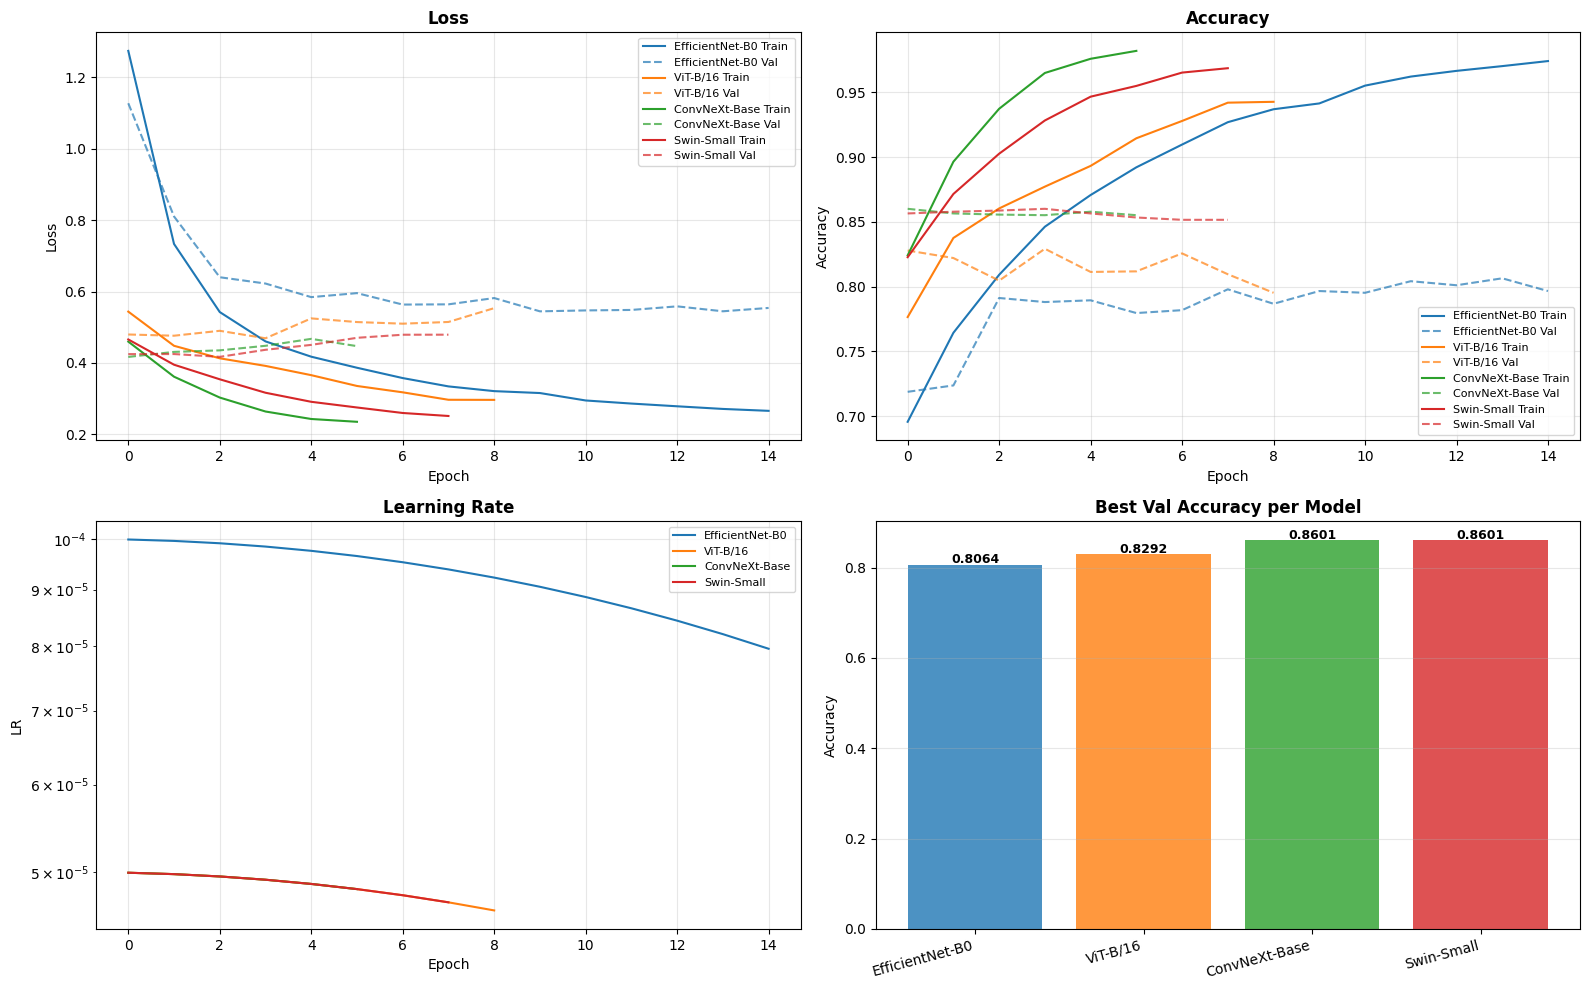

Saved: /kaggle/working/results/training_history.png


In [19]:
# ========================================
# CELL 16: Plot Training History (4 model)
# ========================================

def plot_training_history(histories, model_names, save_path):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for history, name, color in zip(histories, model_names, colors):
        axes[0, 0].plot(history['train_loss'], label=f'{name} Train', color=color)
        axes[0, 0].plot(history['val_loss'], '--', label=f'{name} Val', color=color, alpha=0.7)
        axes[0, 1].plot(history['train_acc'], label=f'{name} Train', color=color)
        axes[0, 1].plot(history['val_acc'], '--', label=f'{name} Val', color=color, alpha=0.7)
        axes[1, 0].plot(history['lr'], label=name, color=color)

    for ax, title, ylabel in zip(
        [axes[0,0], axes[0,1], axes[1,0]],
        ['Loss', 'Accuracy', 'Learning Rate'],
        ['Loss', 'Accuracy', 'LR']
    ):
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel(ylabel); ax.set_xlabel('Epoch')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    axes[1, 0].set_yscale('log')

    best_accs = [max(h['val_acc']) for h in histories]
    bars = axes[1, 1].bar(model_names, best_accs, color=colors, alpha=0.8)
    axes[1, 1].set_title('Best Val Accuracy per Model', fontweight='bold')
    axes[1, 1].set_ylabel('Accuracy'); axes[1, 1].grid(True, axis='y', alpha=0.3)
    axes[1, 1].set_xticklabels(model_names, rotation=15, ha='right')
    for bar, v in zip(bars, best_accs):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 0.003,
                        f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

plot_training_history(
    [efficientnet_history, vit_history, convnext_history, swin_history],
    ['EfficientNet-B0', 'ViT-B/16', 'ConvNeXt-Base', 'Swin-Small'],
    os.path.join(RESULTS_DIR, 'training_history.png')
)

In [36]:
# ========================================
# FIX CELL — Jalankan ini sebelum Cell 17!
# Mendefinisikan ulang semua fungsi yang hilang
# ========================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
import torch
import pandas as pd
import time

# ── evaluate_model ────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate_model(model, dataloader, class_names):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in dataloader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0)
    cm     = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds,
                                   target_names=class_names, zero_division=0)
    return {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'confusion_matrix': cm, 'classification_report': report,
        'predictions': all_preds, 'labels': all_labels, 'probabilities': all_probs
    }

# ── plot_confusion_matrix ─────────────────────────────────────────────────────
def plot_confusion_matrix(cm, class_names, title, save_path):
    plt.figure(figsize=(max(8, len(class_names)*1.5), max(6, len(class_names)*1.2)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title); plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

# ── measure_inference_time ────────────────────────────────────────────────────
def measure_inference_time(model, input_size, num_runs=100, warmup=10):
    model.eval()
    dummy = torch.randn(1, 3, input_size, input_size).to(device)
    with torch.no_grad():
        for _ in range(warmup): model(dummy)
    torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        for _ in range(num_runs):
            model(dummy); torch.cuda.synchronize()
    return (time.time() - t0) / num_runs * 1000

# ── measure_memory_usage ──────────────────────────────────────────────────────
def measure_memory_usage(model, input_size):
    model.eval()
    torch.cuda.reset_peak_memory_stats(); torch.cuda.empty_cache()
    dummy = torch.randn(1, 3, input_size, input_size).to(device)
    with torch.no_grad(): model(dummy)
    return torch.cuda.max_memory_allocated() / (1024 ** 2)

# ── count_flops ───────────────────────────────────────────────────────────────
def count_flops(model, input_size):
    from thop import profile
    dummy = torch.randn(1, 3, input_size, input_size).to(device)
    flops, params = profile(model, inputs=(dummy,), verbose=False)
    return flops / 1e9, params / 1e6

# ── ensemble_metrics ──────────────────────────────────────────────────────────
def ensemble_metrics(probs, labels, class_names, method_name, save_path):
    preds = np.argmax(probs, axis=1)
    acc   = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0)
    cm = confusion_matrix(labels, preds)
    print(f"\n{method_name}:")
    print(f"  Acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}  F1={f1:.4f}")
    plot_confusion_matrix(cm, class_names, f'{method_name} Confusion Matrix', save_path)
    return acc, prec, rec, f1, cm

print("✅ Semua fungsi berhasil didefinisikan ulang!")
print("   - evaluate_model")
print("   - plot_confusion_matrix")
print("   - measure_inference_time")
print("   - measure_memory_usage")
print("   - count_flops")
print("   - ensemble_metrics")
print("\nLanjut jalankan Cell 17 (Evaluate Semua Model)")

✅ Semua fungsi berhasil didefinisikan ulang!
   - evaluate_model
   - plot_confusion_matrix
   - measure_inference_time
   - measure_memory_usage
   - count_flops
   - ensemble_metrics

Lanjut jalankan Cell 17 (Evaluate Semua Model)


Recreating clean models...

Creating efficientnet: efficientnet_b0, classes=2
Total params: 4,010,110 | Trainable: 4,010,110

Creating vit: vit_base_patch16_384, classes=2
Total params: 86,092,034 | Trainable: 86,092,034

Creating convnext: convnext_base, classes=2
Total params: 87,568,514 | Trainable: 87,568,514

Creating swin: swin_small_patch4_window7_224, classes=2
Total params: 48,838,796 | Trainable: 48,838,796

Loading checkpoints...
✅ Loaded: efficientnet_b0_informative  (best val_acc=0.8064)
✅ Loaded: vit_b16_informative  (best val_acc=0.8292)
✅ Loaded: convnext_base_informative  (best val_acc=0.8601)
✅ Loaded: swin_small_informative  (best val_acc=0.8601)

DataLoaders (efficientnet):
  train: 426 batches
  val: 70 batches
  test: 70 batches

DataLoaders (vit):
  train: 851 batches
  val: 140 batches
  test: 140 batches

DataLoaders (convnext):
  train: 426 batches
  val: 70 batches
  test: 70 batches

DataLoaders (swin):
  train: 426 batches
  val: 70 batches
  test: 70 batch

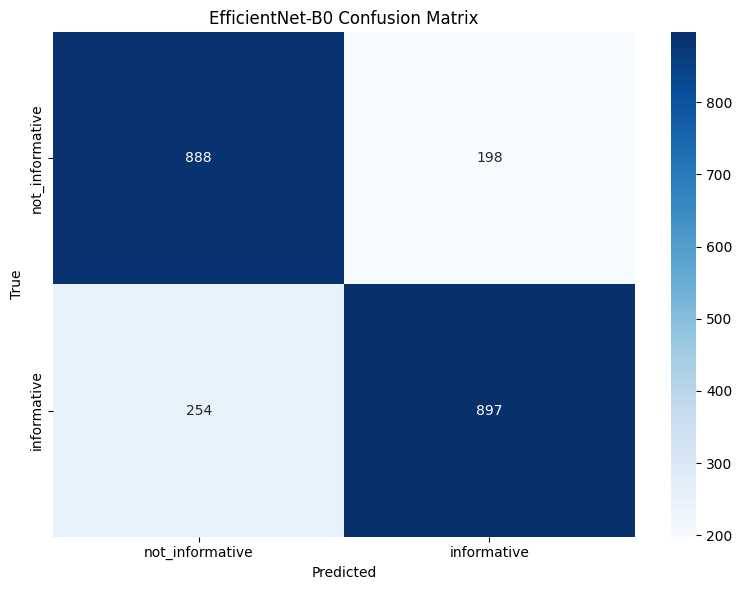

Saved: /kaggle/working/results/efficientnet_b0_cm.png


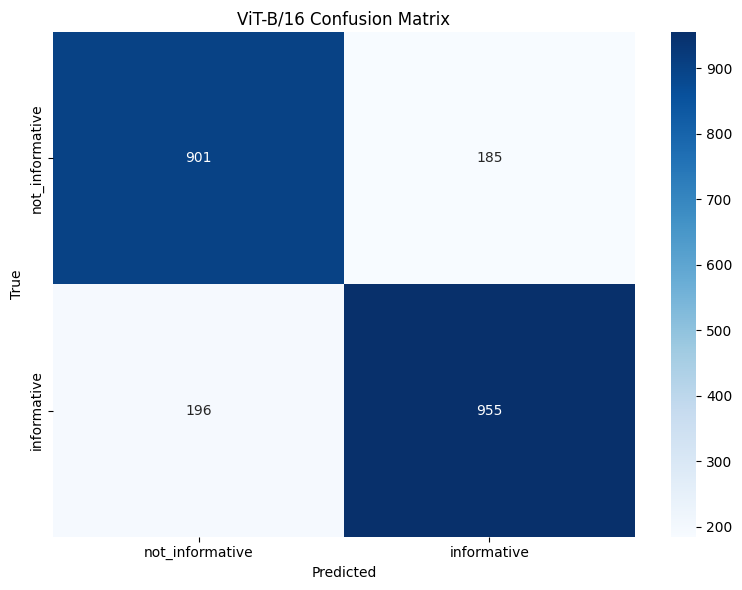

Saved: /kaggle/working/results/vit_b16_cm.png


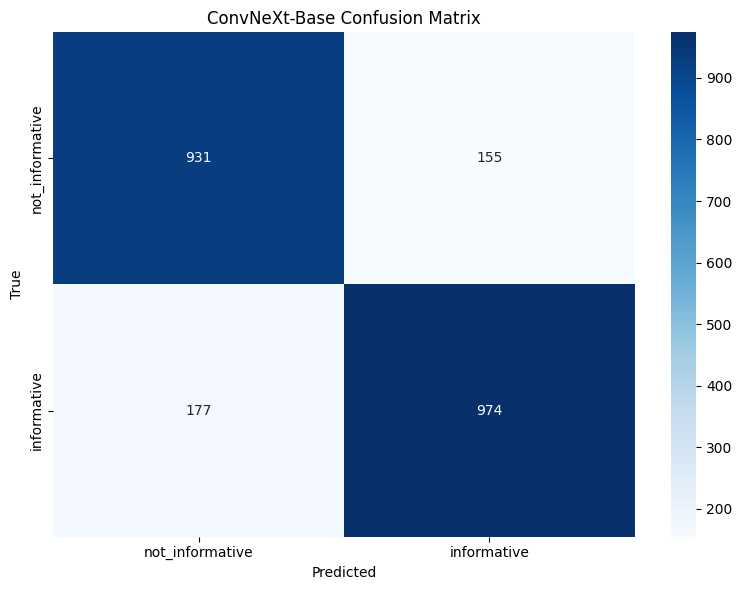

Saved: /kaggle/working/results/convnext_base_cm.png


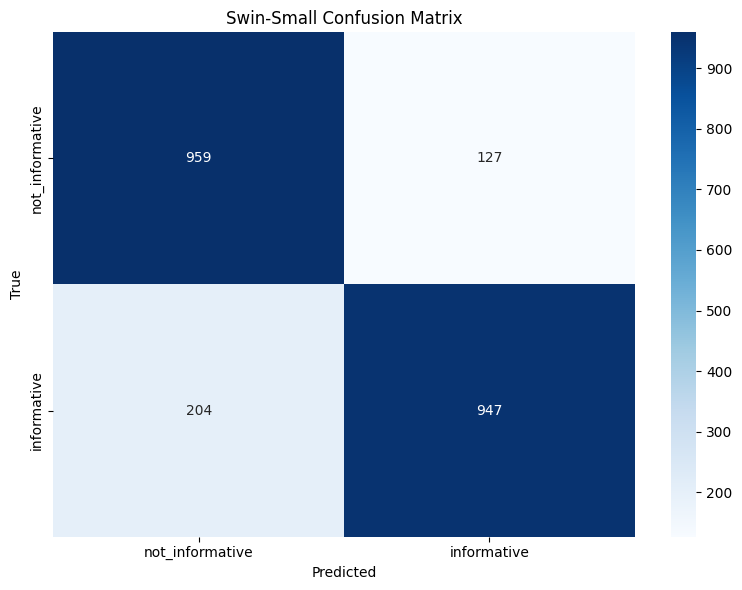

Saved: /kaggle/working/results/swin_small_cm.png

✅ Cell 17 selesai — lanjut Cell 18


In [45]:
# ========================================
# CELL 17 (FIXED v2): Recreate + Load + Evaluate
# ========================================

# Recreate model bersih (tanpa thop buffers)
print("Recreating clean models...")
efficientnet_model = create_model('efficientnet', NUM_CLASSES, pretrained=False)
vit_model          = create_model('vit',          NUM_CLASSES, pretrained=False)
convnext_model     = create_model('convnext',     NUM_CLASSES, pretrained=False)
swin_model         = create_model('swin',         NUM_CLASSES, pretrained=False)

# Load checkpoint ke model yang bersih
print("\nLoading checkpoints...")
for model, name in [
    (efficientnet_model, f'efficientnet_b0_{TASK}'),
    (vit_model,          f'vit_b16_{TASK}'),
    (convnext_model,     f'convnext_base_{TASK}'),
    (swin_model,         f'swin_small_{TASK}'),
]:
    ckpt = torch.load(os.path.join(CHECKPOINT_DIR, f'{name}_best.pth'))
    model.load_state_dict(ckpt['model_state_dict'], strict=True)
    print(f"✅ Loaded: {name}  (best val_acc={ckpt['val_acc']:.4f})")

# Recreate dataloaders karena model baru
efficientnet_loaders = create_dataloaders(data_splits, 'efficientnet',
    MODEL_CONFIG['efficientnet']['batch_size'], TRAIN_CONFIG['num_workers'])
vit_loaders          = create_dataloaders(data_splits, 'vit',
    MODEL_CONFIG['vit']['batch_size'], TRAIN_CONFIG['num_workers'])
convnext_loaders     = create_dataloaders(data_splits, 'convnext',
    MODEL_CONFIG['convnext']['batch_size'], TRAIN_CONFIG['num_workers'])
swin_loaders         = create_dataloaders(data_splits, 'swin',
    MODEL_CONFIG['swin']['batch_size'], TRAIN_CONFIG['num_workers'])

# Evaluate
print("\nEvaluating all models...")
efficientnet_results = evaluate_model(efficientnet_model, efficientnet_loaders['test'], CLASS_NAMES)
vit_results          = evaluate_model(vit_model,          vit_loaders['test'],          CLASS_NAMES)
convnext_results     = evaluate_model(convnext_model,     convnext_loaders['test'],     CLASS_NAMES)
swin_results         = evaluate_model(swin_model,         swin_loaders['test'],         CLASS_NAMES)

for name, res in [
    ('EfficientNet-B0', efficientnet_results),
    ('ViT-B/16',        vit_results),
    ('ConvNeXt-Base',   convnext_results),
    ('Swin-Small',      swin_results),
]:
    print(f"\n{'─'*50}\n{name}")
    print(f"  Acc={res['accuracy']:.4f}  P={res['precision']:.4f}  R={res['recall']:.4f}  F1={res['f1']:.4f}")

for name, res in [
    ('EfficientNet-B0', efficientnet_results),
    ('ViT-B/16',        vit_results),
    ('ConvNeXt-Base',   convnext_results),
    ('Swin-Small',      swin_results),
]:
    plot_confusion_matrix(
        res['confusion_matrix'], CLASS_NAMES,
        f'{name} Confusion Matrix',
        os.path.join(RESULTS_DIR, f'{name.lower().replace("/","").replace("-","_")}_cm.png')
    )

print("\n✅ Cell 17 selesai — lanjut Cell 18")


📊 Val Accuracy & Ensemble Weights:
  Model                   Val Acc     Weight
  ──────────────────────────────────────────
  efficientnet             0.8064     0.2403
  vit                      0.8292     0.2471
  convnext                 0.8601     0.2563
  swin                     0.8601     0.2563

  Model terendah (di-drop untuk Best-3): efficientnet (0.8064)

ENSEMBLE RESULTS

Ensemble Simple (4 model):
  Acc=0.8494  P=0.8501  R=0.8501  F1=0.8494


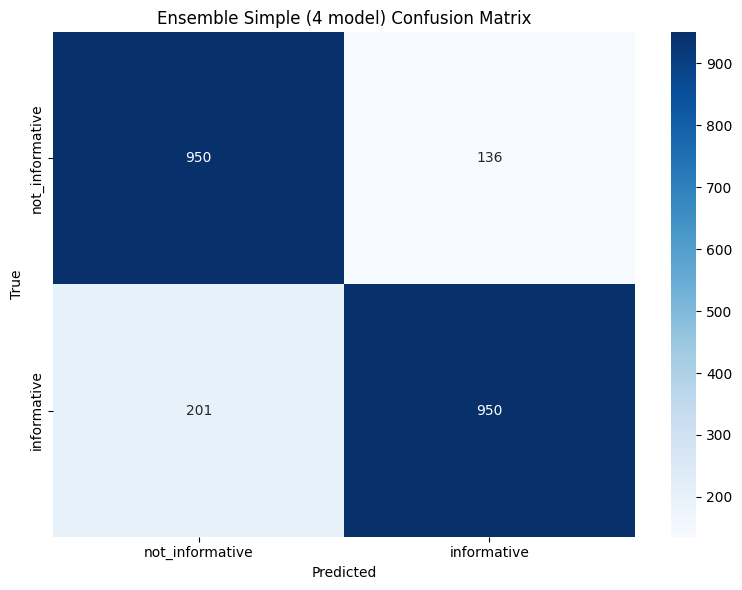

Saved: /kaggle/working/results/ensemble_simple4_cm.png

Ensemble Weighted (4 model):
  Acc=0.8498  P=0.8505  R=0.8505  F1=0.8498


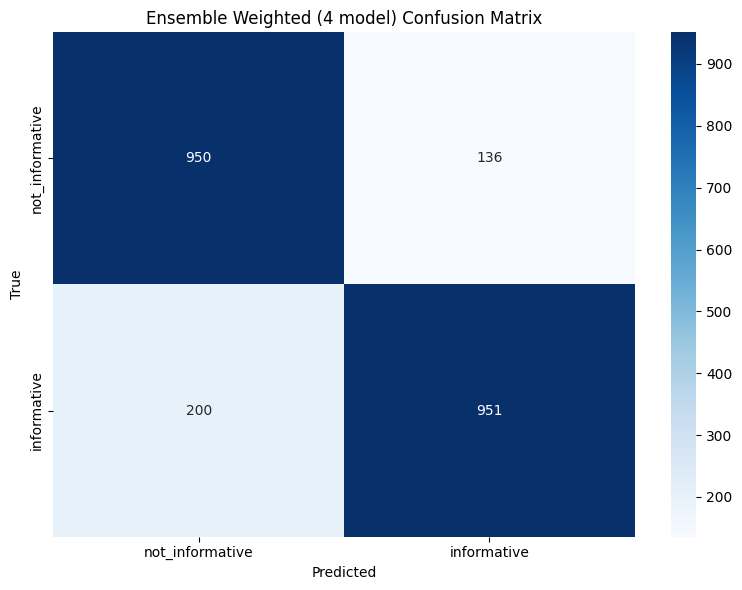

Saved: /kaggle/working/results/ensemble_weighted4_cm.png

Ensemble Best-3 (drop efficientnet):
  Acc=0.8570  P=0.8573  R=0.8575  F1=0.8569


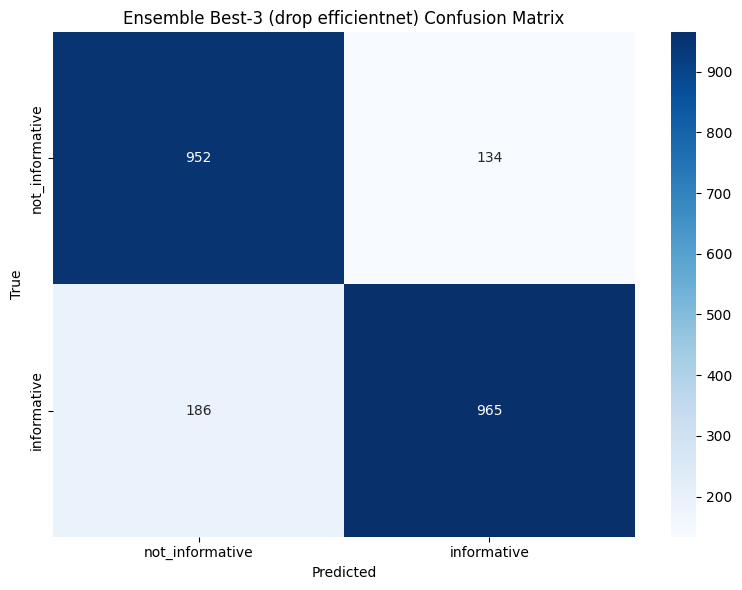

Saved: /kaggle/working/results/ensemble_best3_cm.png


In [46]:
# ========================================
# CELL 18 (BARU): Ensemble 4 Model
# ========================================
"""
Kombinasi ensemble yang akan dibandingkan:
1. Simple (rata-rata 4 model)
2. Weighted (berdasarkan val accuracy masing-masing)
3. Best 3 (drop model dengan val_acc terendah)
"""

eff_probs  = efficientnet_results['probabilities']
vit_probs  = vit_results['probabilities']
cnx_probs  = convnext_results['probabilities']
swn_probs  = swin_results['probabilities']
test_labels = efficientnet_results['labels']

# Hitung weights dari val accuracy
val_accs = {
    'efficientnet': max(efficientnet_history['val_acc']),
    'vit':          max(vit_history['val_acc']),
    'convnext':     max(convnext_history['val_acc']),
    'swin':         max(swin_history['val_acc']),
}
total = sum(val_accs.values())
weights = {k: v / total for k, v in val_accs.items()}

print("\n📊 Val Accuracy & Ensemble Weights:")
print(f"  {'Model':<20} {'Val Acc':>10} {'Weight':>10}")
print(f"  {'─'*42}")
for k, v in val_accs.items():
    print(f"  {k:<20} {v:>10.4f} {weights[k]:>10.4f}")

# ── Ensemble 1: Simple (4 model) ─────────────────────────────────────────────
simple_4_probs = (eff_probs + vit_probs + cnx_probs + swn_probs) / 4

# ── Ensemble 2: Weighted (4 model) ───────────────────────────────────────────
weighted_4_probs = (
    weights['efficientnet'] * eff_probs +
    weights['vit']          * vit_probs +
    weights['convnext']     * cnx_probs +
    weights['swin']         * swn_probs
)

# ── Ensemble 3: Best 3 (drop model terendah) ─────────────────────────────────
worst_model = min(val_accs, key=val_accs.get)
print(f"\n  Model terendah (di-drop untuk Best-3): {worst_model} ({val_accs[worst_model]:.4f})")

best3_map = {
    'efficientnet': eff_probs,
    'vit': vit_probs,
    'convnext': cnx_probs,
    'swin': swn_probs
}
best3_probs_list = [v for k, v in best3_map.items() if k != worst_model]
best3_probs = sum(best3_probs_list) / len(best3_probs_list)

# ── Hitung metrics semua ensemble ────────────────────────────────────────────
def ensemble_metrics(probs, labels, class_names, method_name, save_path):
    preds = np.argmax(probs, axis=1)
    acc   = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0)
    cm = confusion_matrix(labels, preds)
    print(f"\n{method_name}:")
    print(f"  Acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}  F1={f1:.4f}")
    plot_confusion_matrix(cm, class_names, f'{method_name} Confusion Matrix', save_path)
    return acc, prec, rec, f1, cm

print("\n" + "="*60)
print("ENSEMBLE RESULTS")
print("="*60)

(s4_acc, s4_prec, s4_rec, s4_f1, _) = ensemble_metrics(
    simple_4_probs, test_labels, CLASS_NAMES,
    'Ensemble Simple (4 model)',
    os.path.join(RESULTS_DIR, 'ensemble_simple4_cm.png'))

(w4_acc, w4_prec, w4_rec, w4_f1, _) = ensemble_metrics(
    weighted_4_probs, test_labels, CLASS_NAMES,
    'Ensemble Weighted (4 model)',
    os.path.join(RESULTS_DIR, 'ensemble_weighted4_cm.png'))

(b3_acc, b3_prec, b3_rec, b3_f1, _) = ensemble_metrics(
    best3_probs, test_labels, CLASS_NAMES,
    f'Ensemble Best-3 (drop {worst_model})',
    os.path.join(RESULTS_DIR, 'ensemble_best3_cm.png'))


In [47]:
# ========================================
# CELL 19: Efficiency Metrics (4 model)
# ========================================

def measure_inference_time(model, input_size, num_runs=100, warmup=10):
    model.eval()
    dummy = torch.randn(1, 3, input_size, input_size).to(device)
    with torch.no_grad():
        for _ in range(warmup): model(dummy)
    torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        for _ in range(num_runs):
            model(dummy); torch.cuda.synchronize()
    return (time.time() - t0) / num_runs * 1000

def measure_memory_usage(model, input_size):
    model.eval()
    torch.cuda.reset_peak_memory_stats(); torch.cuda.empty_cache()
    dummy = torch.randn(1, 3, input_size, input_size).to(device)
    with torch.no_grad(): model(dummy)
    return torch.cuda.max_memory_allocated() / (1024 ** 2)

def count_flops(model, input_size):
    from thop import profile
    dummy = torch.randn(1, 3, input_size, input_size).to(device)
    flops, params = profile(model, inputs=(dummy,), verbose=False)
    return flops / 1e9, params / 1e6

print("\nMeasuring efficiency metrics...")
metrics = {}
for key, model, size in [
    ('efficientnet', efficientnet_model, 224),
    ('vit',          vit_model,          384),
    ('convnext',     convnext_model,     224),
    ('swin',         swin_model,         224),
]:
    t     = measure_inference_time(model, size)
    mem   = measure_memory_usage(model, size)
    flops, params = count_flops(model, size)
    metrics[key] = {'time': t, 'memory': mem, 'flops': flops, 'params': params}
    print(f"  {key:<15} → {t:.1f}ms  {mem:.0f}MB  {flops:.2f}G  {params:.1f}M params")

# Ensemble metrics (sum semua 4 model)
ens4_time   = sum(m['time']   for m in metrics.values())
ens4_mem    = sum(m['memory'] for m in metrics.values())
ens4_flops  = sum(m['flops']  for m in metrics.values())
ens4_params = sum(m['params'] for m in metrics.values())

# Best-3 ensemble (kurangi model terendah)
b3_time   = ens4_time   - metrics[worst_model]['time']
b3_mem    = ens4_mem    - metrics[worst_model]['memory']
b3_flops  = ens4_flops  - metrics[worst_model]['flops']
b3_params = ens4_params - metrics[worst_model]['params']



Measuring efficiency metrics...
  efficientnet    → 8.6ms  1551MB  0.38G  4.0M params
  vit             → 42.9ms  1562MB  49.35G  85.6M params
  convnext        → 15.7ms  1556MB  15.35G  87.5M params
  swin            → 23.4ms  1555MB  8.54G  48.8M params


In [48]:
# ========================================
# CELL 20: Summary Table Lengkap
# ========================================

rows = []
for key, name, res, hist in [
    ('efficientnet', 'EfficientNet-B0', efficientnet_results, efficientnet_history),
    ('vit',          'ViT-B/16',        vit_results,          vit_history),
    ('convnext',     'ConvNeXt-Base',   convnext_results,     convnext_history),
    ('swin',         'Swin-Small',      swin_results,         swin_history),
]:
    m = metrics[key]
    rows.append({
        'Model':       name,
        'Accuracy':    res['accuracy'],
        'Precision':   res['precision'],
        'Recall':      res['recall'],
        'F1-Score':    res['f1'],
        'Time (ms)':   m['time'],
        'Memory (MB)': m['memory'],
        'FLOPs (G)':   m['flops'],
        'Params (M)':  m['params'],
    })

# Tambahkan ensemble
for ens_name, acc, prec, rec, f1, t, mem, flops, params in [
    ('Ensemble Simple (4)',    s4_acc, s4_prec, s4_rec, s4_f1,
     ens4_time, ens4_mem, ens4_flops, ens4_params),
    ('Ensemble Weighted (4)',  w4_acc, w4_prec, w4_rec, w4_f1,
     ens4_time, ens4_mem, ens4_flops, ens4_params),
    (f'Ensemble Best-3',       b3_acc, b3_prec, b3_rec, b3_f1,
     b3_time, b3_mem, b3_flops, b3_params),
]:
    rows.append({
        'Model': ens_name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1,
        'Time (ms)': t, 'Memory (MB)': mem, 'FLOPs (G)': flops, 'Params (M)': params,
    })

results_df = pd.DataFrame(rows)

print("\n" + "="*90)
print("SUMMARY RESULTS")
print("="*90)
print(results_df.to_string(index=False, float_format='{:.4f}'.format))
results_df.to_csv(os.path.join(RESULTS_DIR, 'summary_results_v2.csv'), index=False)



SUMMARY RESULTS
                Model  Accuracy  Precision  Recall  F1-Score  Time (ms)  Memory (MB)  FLOPs (G)  Params (M)
      EfficientNet-B0    0.7979     0.7984  0.7985    0.7979     8.5576    1550.7490     0.3846      3.9681
             ViT-B/16    0.8297     0.8295  0.8297    0.8296    42.8512    1561.9336    49.3470     85.6097
        ConvNeXt-Base    0.8516     0.8515  0.8517    0.8515    15.6569    1556.2109    15.3538     87.5103
           Swin-Small    0.8520     0.8532  0.8529    0.8520    23.3564    1555.3599     8.5442     48.7911
  Ensemble Simple (4)    0.8494     0.8501  0.8501    0.8494    90.4221    6224.2534    73.6296    225.8792
Ensemble Weighted (4)    0.8498     0.8505  0.8505    0.8498    90.4221    6224.2534    73.6296    225.8792
      Ensemble Best-3    0.8570     0.8573  0.8575    0.8569    81.8644    4673.5044    73.2450    221.9111


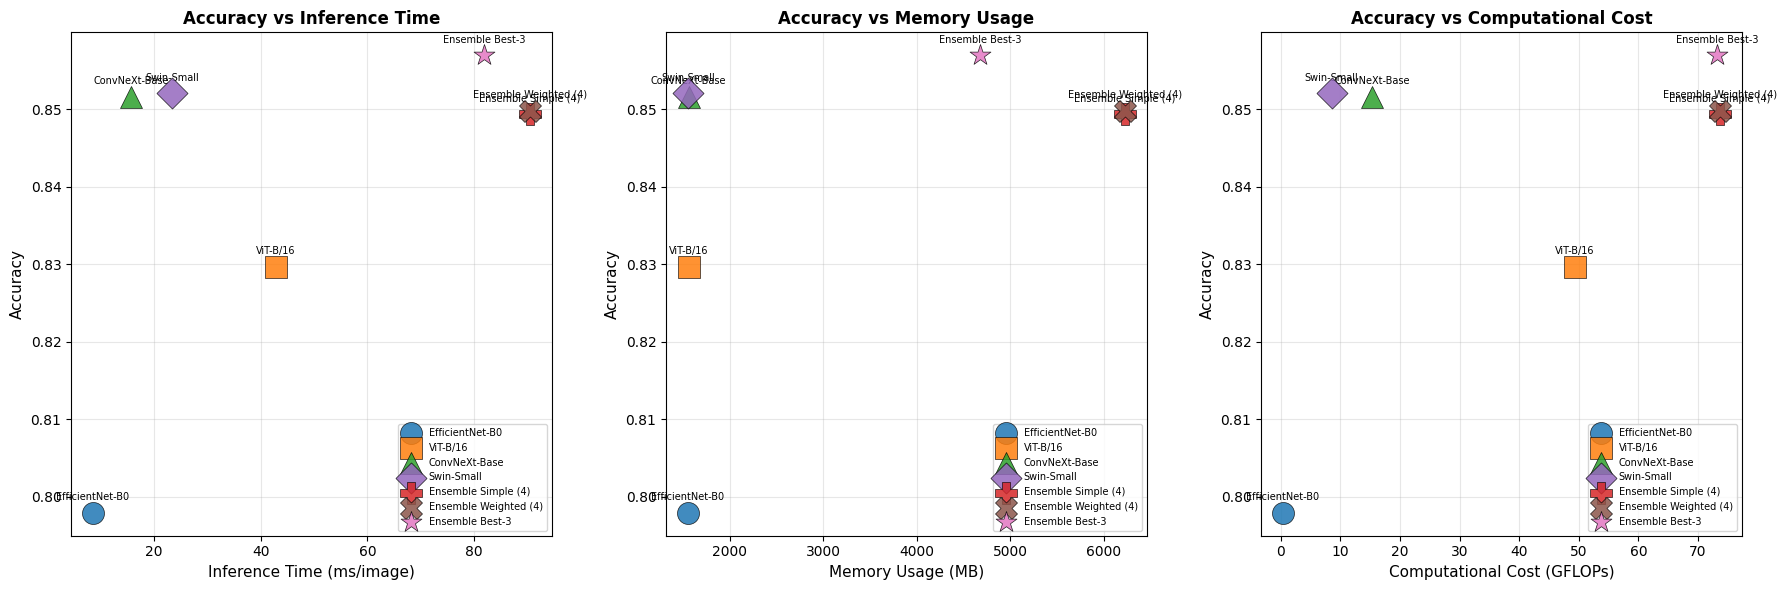

In [49]:
# ========================================
# CELL 21: Trade-off Visualization
# ========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd',  # 4 single models
           '#d62728', '#8c564b', '#e377c2']               # ensembles
markers = ['o', 's', '^', 'D', 'P', 'X', '*']

for ax, xcol, xlabel in zip(
    axes,
    ['Time (ms)', 'Memory (MB)', 'FLOPs (G)'],
    ['Inference Time (ms/image)', 'Memory Usage (MB)', 'Computational Cost (GFLOPs)']
):
    for i, (_, row) in enumerate(results_df.iterrows()):
        ax.scatter(row[xcol], row['Accuracy'], s=250,
                   c=colors[i % len(colors)], marker=markers[i % len(markers)],
                   label=row['Model'], alpha=0.85, zorder=5,
                   edgecolors='black', linewidths=0.5)
        ax.annotate(row['Model'],
                    (row[xcol], row['Accuracy']),
                    textcoords='offset points', xytext=(0, 9),
                    ha='center', fontsize=7)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title(f'Accuracy vs {xlabel.split("(")[0].strip()}',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'tradeoff_analysis_v2.png'), dpi=300, bbox_inches='tight')
plt.show()


In [50]:
# ========================================
# CELL 22: Final Summary
# ========================================

best_idx = results_df['Accuracy'].idxmax()
best_row = results_df.loc[best_idx]

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\n🏆 Best Model  : {best_row['Model']}")
print(f"   Accuracy    : {best_row['Accuracy']:.4f}")
print(f"   F1-Score    : {best_row['F1-Score']:.4f}")
print(f"   Time (ms)   : {best_row['Time (ms)']:.2f}")
print(f"   Memory (MB) : {best_row['Memory (MB)']:.0f}")

print("\n📊 Accuracy Ranking:")
ranked = results_df[['Model', 'Accuracy', 'F1-Score', 'Time (ms)']].sort_values(
    'Accuracy', ascending=False)
print(ranked.to_string(index=False, float_format='{:.4f}'.format))

# Hitung gain vs baseline (EfficientNet-B0)
baseline_acc = results_df[results_df['Model'] == 'EfficientNet-B0']['Accuracy'].values[0]
print(f"\n📈 Accuracy Gain vs EfficientNet-B0 (baseline={baseline_acc:.4f}):")
for _, row in results_df.iterrows():
    gain = row['Accuracy'] - baseline_acc
    sign = '+' if gain >= 0 else ''
    print(f"   {row['Model']:<30} {sign}{gain*100:.2f}%")

# Save JSON
all_results = {
    'task': TASK,
    'num_classes': NUM_CLASSES,
    'label_smoothing': TRAIN_CONFIG['label_smoothing'],
    'models': {}
}
for _, row in results_df.iterrows():
    all_results['models'][row['Model']] = {
        k: float(v) for k, v in row.items() if k != 'Model'
    }
with open(os.path.join(RESULTS_DIR, 'all_results_v2.json'), 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\n✅ Semua hasil disimpan di: {RESULTS_DIR}")
print("="*70)


FINAL SUMMARY

🏆 Best Model  : Ensemble Best-3
   Accuracy    : 0.8570
   F1-Score    : 0.8569
   Time (ms)   : 81.86
   Memory (MB) : 4674

📊 Accuracy Ranking:
                Model  Accuracy  F1-Score  Time (ms)
      Ensemble Best-3    0.8570    0.8569    81.8644
           Swin-Small    0.8520    0.8520    23.3564
        ConvNeXt-Base    0.8516    0.8515    15.6569
Ensemble Weighted (4)    0.8498    0.8498    90.4221
  Ensemble Simple (4)    0.8494    0.8494    90.4221
             ViT-B/16    0.8297    0.8296    42.8512
      EfficientNet-B0    0.7979    0.7979     8.5576

📈 Accuracy Gain vs EfficientNet-B0 (baseline=0.7979):
   EfficientNet-B0                +0.00%
   ViT-B/16                       +3.17%
   ConvNeXt-Base                  +5.36%
   Swin-Small                     +5.41%
   Ensemble Simple (4)            +5.14%
   Ensemble Weighted (4)          +5.19%
   Ensemble Best-3                +5.90%

✅ Semua hasil disimpan di: /kaggle/working/results


In [43]:
# ========================================
# CELL 23: Kumpulkan Probabilitas untuk Stacking
# ========================================
"""
Langkah 1 Stacking:
- Jalankan 4 model pada VALIDATION SET → untuk train meta-model
- Jalankan 4 model pada TEST SET → untuk evaluasi meta-model
- Hasilnya: feature matrix berisi probabilitas output tiap model
"""

@torch.no_grad()
def get_probabilities(model, dataloader):
    """Ambil probabilitas output model untuk semua data di dataloader"""
    model.eval()
    all_probs  = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc='Extracting probs', leave=False):
        images = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_labels)


print("Mengumpulkan probabilitas dari 4 model...\n")

# ── VALIDATION SET (untuk train meta-model) ───────────────────────────────────
print("=== Validation Set ===")
eff_val_probs,  val_labels  = get_probabilities(efficientnet_model, efficientnet_loaders['val'])
vit_val_probs,  _           = get_probabilities(vit_model,          vit_loaders['val'])
cnx_val_probs,  _           = get_probabilities(convnext_model,     convnext_loaders['val'])
swn_val_probs,  _           = get_probabilities(swin_model,         swin_loaders['val'])

# ── TEST SET (untuk evaluasi akhir) ───────────────────────────────────────────
print("\n=== Test Set ===")
eff_test_probs,  test_labels = get_probabilities(efficientnet_model, efficientnet_loaders['test'])
vit_test_probs,  _           = get_probabilities(vit_model,          vit_loaders['test'])
cnx_test_probs,  _           = get_probabilities(convnext_model,     convnext_loaders['test'])
swn_test_probs,  _           = get_probabilities(swin_model,         swin_loaders['test'])

# ── Gabungkan jadi feature matrix ─────────────────────────────────────────────
# Shape: (n_samples, 4_models × num_classes)
# Contoh binary: (n_samples, 8)  |  humanitarian: (n_samples, 28)
X_val  = np.concatenate([eff_val_probs,  vit_val_probs,  cnx_val_probs,  swn_val_probs],  axis=1)
X_test = np.concatenate([eff_test_probs, vit_test_probs, cnx_test_probs, swn_test_probs], axis=1)
y_val  = val_labels
y_test = test_labels

print(f"\nShape feature matrix:")
print(f"  X_val  : {X_val.shape}  → ({len(val_labels)} samples, {X_val.shape[1]} features)")
print(f"  X_test : {X_test.shape}  → ({len(test_labels)} samples, {X_test.shape[1]} features)")
print(f"\nKolom fitur:")
feat_names = []
for model_name in ['EfficientNet', 'ViT', 'ConvNeXt', 'Swin']:
    for cls in CLASS_NAMES:
        feat_names.append(f"{model_name}_{cls}")
print(f"  {feat_names}")


Mengumpulkan probabilitas dari 4 model...

=== Validation Set ===


Extracting probs:   0%|          | 0/70 [00:00<?, ?it/s]

Extracting probs:   0%|          | 0/140 [00:00<?, ?it/s]

Extracting probs:   0%|          | 0/70 [00:00<?, ?it/s]

Extracting probs:   0%|          | 0/70 [00:00<?, ?it/s]

...

Extracting probs:   0%|          | 0/70 [00:00<?, ?it/s]

Extracting probs:   0%|          | 0/140 [00:00<?, ?it/s]

Extracting probs:   0%|          | 0/70 [00:00<?, ?it/s]

Extracting probs:   0%|          | 0/70 [00:00<?, ?it/s]


Shape feature matrix:
  X_val  : (2237, 8)  → (2237 samples, 8 features)
  X_test : (2237, 8)  → (2237 samples, 8 features)

Kolom fitur:
  ['EfficientNet_not_informative', 'EfficientNet_informative', 'ViT_not_informative', 'ViT_informative', 'ConvNeXt_not_informative', 'ConvNeXt_informative', 'Swin_not_informative', 'Swin_informative']


Training Meta-Model 1: Logistic Regression
  Accuracy  : 0.8592
  Precision : 0.8599
  Recall    : 0.8599
  F1-Score  : 0.8592

                 precision    recall  f1-score   support

not_informative       0.84      0.88      0.86      1086
    informative       0.88      0.84      0.86      1151

       accuracy                           0.86      2237
      macro avg       0.86      0.86      0.86      2237
   weighted avg       0.86      0.86      0.86      2237



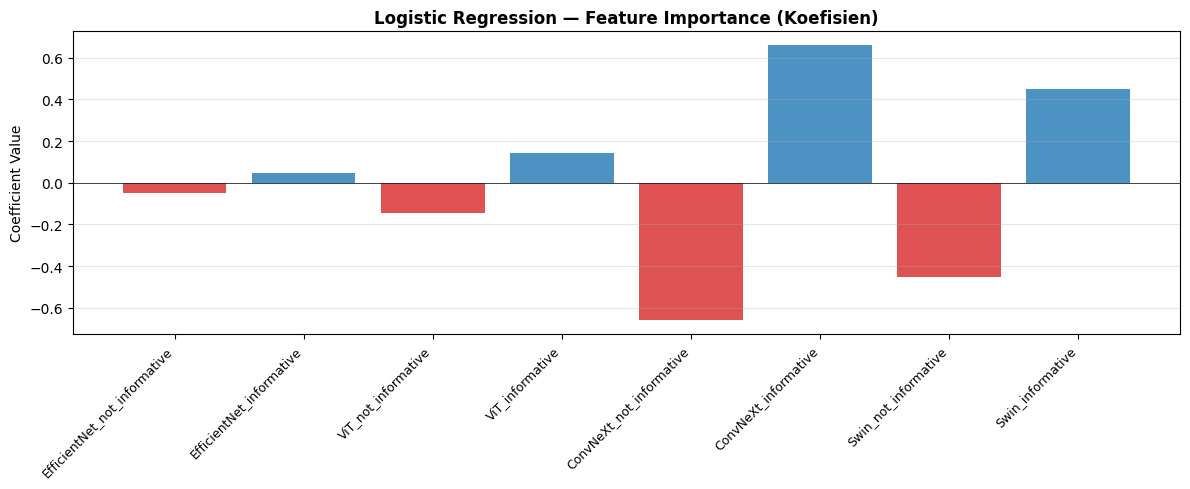

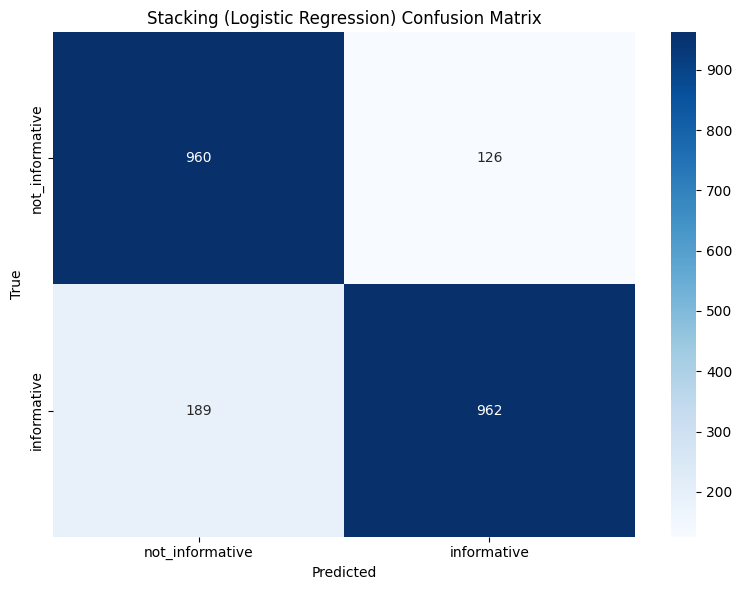

Saved: /kaggle/working/results/stacking_lr_cm.png


In [51]:
# ========================================
# CELL 24: Meta-Model 1 — Logistic Regression
# ========================================
"""
Meta-model paling simpel & interpretable.
Cocok sebagai baseline stacking.
"""

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("Training Meta-Model 1: Logistic Regression")
print("=" * 50)

# Pipeline: scaling + logistic regression
# Scaling penting karena probabilitas tiap model bisa punya distribusi berbeda
lr_meta = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
        max_iter=1000,
        C=1.0,               # regularization
        random_state=42,
        class_weight='balanced'  # handle class imbalance
    ))
])

lr_meta.fit(X_val, y_val)

# Evaluasi
lr_preds = lr_meta.predict(X_test)
lr_probs = lr_meta.predict_proba(X_test)

lr_acc  = accuracy_score(y_test, lr_preds)
lr_prec, lr_rec, lr_f1, _ = precision_recall_fscore_support(
    y_test, lr_preds, average='macro', zero_division=0)

print(f"  Accuracy  : {lr_acc:.4f}")
print(f"  Precision : {lr_prec:.4f}")
print(f"  Recall    : {lr_rec:.4f}")
print(f"  F1-Score  : {lr_f1:.4f}")
print(f"\n{classification_report(y_test, lr_preds, target_names=CLASS_NAMES, zero_division=0)}")

# Visualisasi feature importance (koefisien LR)
if NUM_CLASSES == 2:
    # Binary: satu set koefisien
    coef = lr_meta.named_steps['clf'].coef_[0]
    plt.figure(figsize=(12, 5))
    colors_bar = ['#1f77b4' if c >= 0 else '#d62728' for c in coef]
    plt.bar(feat_names, coef, color=colors_bar, alpha=0.8)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.title('Logistic Regression — Feature Importance (Koefisien)', fontweight='bold')
    plt.ylabel('Coefficient Value')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'stacking_lr_importance.png'), dpi=300, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(
    confusion_matrix(y_test, lr_preds), CLASS_NAMES,
    'Stacking (Logistic Regression) Confusion Matrix',
    os.path.join(RESULTS_DIR, 'stacking_lr_cm.png')
)



Meta-model train size : 1789
Meta-model val size   : 448

Training Meta-Model 2: MLP
Training MLP meta-model (8→64→32→2)
  Epoch  20/200 | loss=0.3785 | val_acc=0.8393 | best=0.8438
  Epoch  40/200 | loss=0.3328 | val_acc=0.8460 | best=0.8549
  ⏹ Early stopping at epoch 44
  ✅ Best val_acc: 0.8549

MLP Test Results:
  Accuracy  : 0.8431
  Precision : 0.8514
  Recall    : 0.8453
  F1-Score  : 0.8427

                 precision    recall  f1-score   support

not_informative       0.79      0.92      0.85      1086
    informative       0.91      0.77      0.83      1151

       accuracy                           0.84      2237
      macro avg       0.85      0.85      0.84      2237
   weighted avg       0.85      0.84      0.84      2237



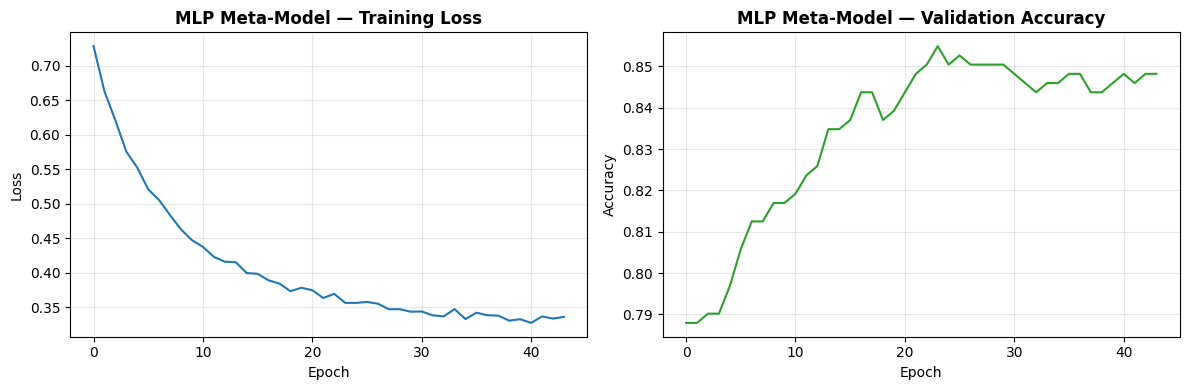

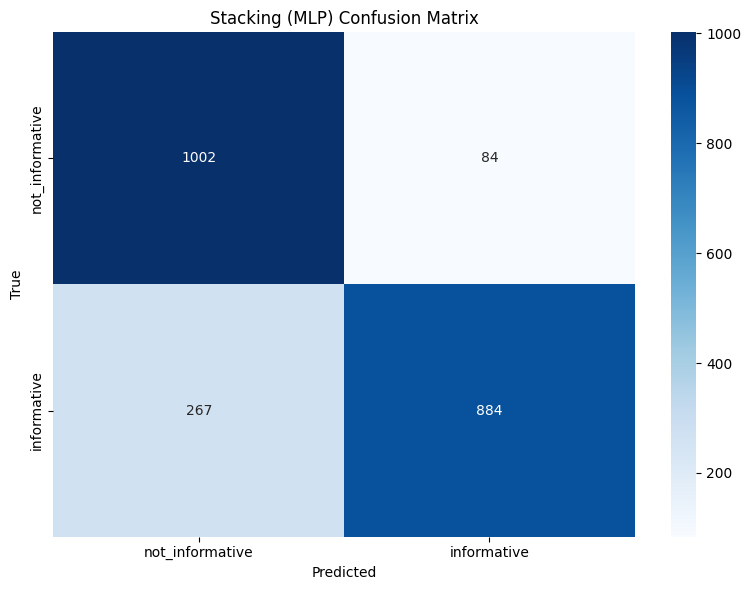

Saved: /kaggle/working/results/stacking_mlp_cm.png


In [52]:
# ========================================
# CELL 25: Meta-Model 2 — MLP (Neural Network Kecil)
# ========================================
"""
Meta-model MLP: lebih powerful dari LR karena bisa tangkap
interaksi non-linear antar probabilitas model.
Tetap kecil agar tidak overfit pada validation set.
"""

import torch.nn as nn

class MetaMLP(nn.Module):
    """
    MLP kecil sebagai meta-model stacking.
    Input  : 4 × num_classes probabilitas
    Output : num_classes logits
    """
    def __init__(self, input_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


def train_meta_mlp(X_train, y_train, X_val_eval, y_val_eval,
                   num_classes, epochs=100, lr=1e-3, hidden_dim=64):
    """Train MLP meta-model dengan early stopping"""

    # Konversi ke tensor
    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.LongTensor(y_train).to(device)
    X_vl = torch.FloatTensor(X_val_eval).to(device)
    y_vl = torch.LongTensor(y_val_eval).to(device)

    input_dim = X_train.shape[1]
    model_mlp = MetaMLP(input_dim, hidden_dim, num_classes).to(device)

    optimizer = optim.Adam(model_mlp.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_val_acc  = 0.0
    best_state    = None
    patience_cnt  = 0
    patience_max  = 20

    history = {'train_loss': [], 'val_acc': []}

    print(f"Training MLP meta-model ({input_dim}→{hidden_dim}→{hidden_dim//2}→{num_classes})")
    for epoch in range(epochs):
        # Train
        model_mlp.train()
        optimizer.zero_grad()
        out  = model_mlp(X_tr)
        loss = criterion(out, y_tr)
        loss.backward()
        optimizer.step()

        # Val
        model_mlp.eval()
        with torch.no_grad():
            val_out  = model_mlp(X_vl)
            val_preds = val_out.argmax(dim=1)
            val_acc  = (val_preds == y_vl).float().mean().item()

        scheduler.step(1 - val_acc)
        history['train_loss'].append(loss.item())
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model_mlp.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | loss={loss.item():.4f} | val_acc={val_acc:.4f} | best={best_val_acc:.4f}")

        if patience_cnt >= patience_max:
            print(f"  ⏹ Early stopping at epoch {epoch+1}")
            break

    # Load best weights
    model_mlp.load_state_dict(best_state)
    print(f"  ✅ Best val_acc: {best_val_acc:.4f}")
    return model_mlp, history


# Bagi X_val jadi train_meta dan val_meta (80/20) untuk menghindari overfit
from sklearn.model_selection import train_test_split

X_meta_train, X_meta_val, y_meta_train, y_meta_val = train_test_split(
    X_val, y_val, test_size=0.2, random_state=42, stratify=y_val
)

print(f"\nMeta-model train size : {len(X_meta_train)}")
print(f"Meta-model val size   : {len(X_meta_val)}")

print("\n" + "="*50)
print("Training Meta-Model 2: MLP")
print("="*50)

mlp_meta, mlp_history = train_meta_mlp(
    X_meta_train, y_meta_train,
    X_meta_val,   y_meta_val,
    num_classes=NUM_CLASSES,
    epochs=200,
    lr=1e-3,
    hidden_dim=64
)

# Evaluasi MLP pada test set
mlp_meta.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    mlp_out   = mlp_meta(X_test_tensor)
    mlp_probs = torch.softmax(mlp_out, dim=1).cpu().numpy()
    mlp_preds = mlp_probs.argmax(axis=1)

mlp_acc  = accuracy_score(y_test, mlp_preds)
mlp_prec, mlp_rec, mlp_f1, _ = precision_recall_fscore_support(
    y_test, mlp_preds, average='macro', zero_division=0)

print(f"\nMLP Test Results:")
print(f"  Accuracy  : {mlp_acc:.4f}")
print(f"  Precision : {mlp_prec:.4f}")
print(f"  Recall    : {mlp_rec:.4f}")
print(f"  F1-Score  : {mlp_f1:.4f}")
print(f"\n{classification_report(y_test, mlp_preds, target_names=CLASS_NAMES, zero_division=0)}")

# Plot MLP training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mlp_history['train_loss'], color='#1f77b4')
axes[0].set_title('MLP Meta-Model — Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(True, alpha=0.3)

axes[1].plot(mlp_history['val_acc'], color='#2ca02c')
axes[1].set_title('MLP Meta-Model — Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'stacking_mlp_history.png'), dpi=300, bbox_inches='tight')
plt.show()

plot_confusion_matrix(
    confusion_matrix(y_test, mlp_preds), CLASS_NAMES,
    'Stacking (MLP) Confusion Matrix',
    os.path.join(RESULTS_DIR, 'stacking_mlp_cm.png')
)

Training Meta-Model 3: Random Forest
  Accuracy  : 0.8565
  Precision : 0.8569
  Recall    : 0.8571
  F1-Score  : 0.8565


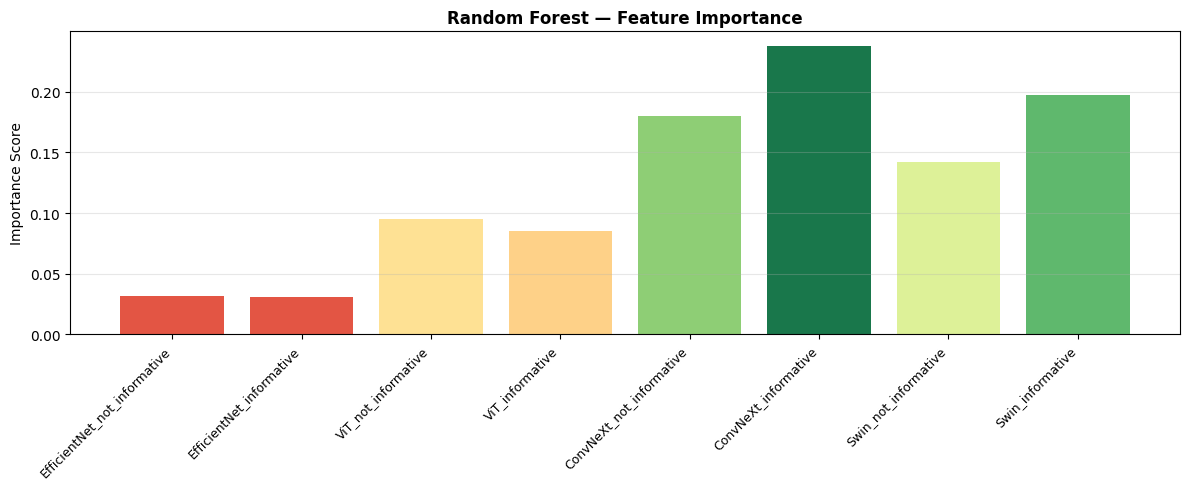

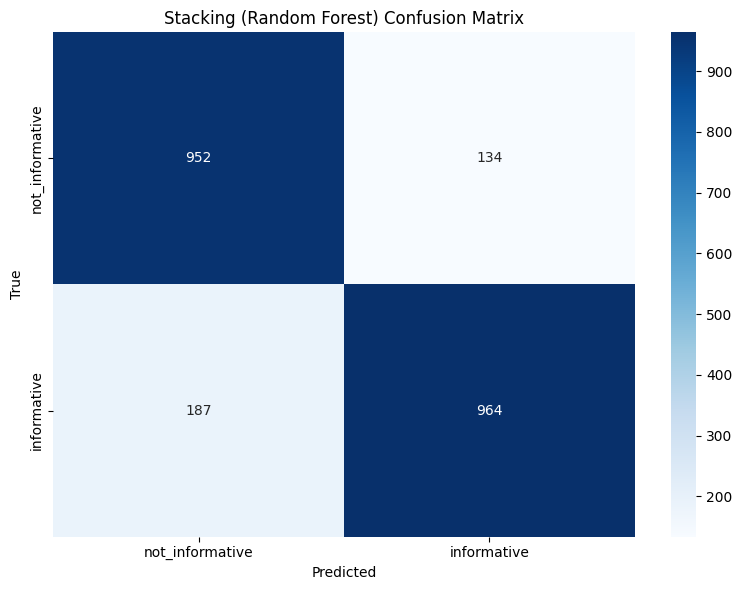

Saved: /kaggle/working/results/stacking_rf_cm.png


In [53]:
# ========================================
# CELL 26: Meta-Model 3 — Random Forest
# ========================================
"""
Sebagai pembanding: Random Forest sebagai meta-model.
Robust terhadap outlier, tidak perlu scaling.
"""

from sklearn.ensemble import RandomForestClassifier

print("Training Meta-Model 3: Random Forest")
print("=" * 50)

rf_meta = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_meta.fit(X_val, y_val)  # Train pada full val set

rf_preds = rf_meta.predict(X_test)
rf_probs = rf_meta.predict_proba(X_test)

rf_acc  = accuracy_score(y_test, rf_preds)
rf_prec, rf_rec, rf_f1, _ = precision_recall_fscore_support(
    y_test, rf_preds, average='macro', zero_division=0)

print(f"  Accuracy  : {rf_acc:.4f}")
print(f"  Precision : {rf_prec:.4f}")
print(f"  Recall    : {rf_rec:.4f}")
print(f"  F1-Score  : {rf_f1:.4f}")

# Feature importance RF
importances = rf_meta.feature_importances_
plt.figure(figsize=(12, 5))
colors_bar = plt.cm.RdYlGn(importances / importances.max())
plt.bar(feat_names, importances, color=colors_bar, alpha=0.9)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Random Forest — Feature Importance', fontweight='bold')
plt.ylabel('Importance Score')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'stacking_rf_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

plot_confusion_matrix(
    confusion_matrix(y_test, rf_preds), CLASS_NAMES,
    'Stacking (Random Forest) Confusion Matrix',
    os.path.join(RESULTS_DIR, 'stacking_rf_cm.png')
)

In [54]:
# ========================================
# CELL 27: Summary Lengkap (v2 + Stacking)
# ========================================

print("\n" + "="*90)
print("SUMMARY LENGKAP — Individual + Ensemble + Stacking")
print("="*90)

# Ambil hasil v2 dari results_df (sudah ada dari Cell 20)
# Tambahkan baris stacking
stacking_rows = [
    {
        'Model':       'Stacking (Logistic Reg)',
        'Accuracy':    lr_acc,
        'Precision':   lr_prec,
        'Recall':      lr_rec,
        'F1-Score':    lr_f1,
        'Time (ms)':   None,   # meta-model sangat cepat, diabaikan
        'Memory (MB)': None,
        'FLOPs (G)':   None,
        'Params (M)':  None,
    },
    {
        'Model':       'Stacking (MLP)',
        'Accuracy':    mlp_acc,
        'Precision':   mlp_prec,
        'Recall':      mlp_rec,
        'F1-Score':    mlp_f1,
        'Time (ms)':   None,
        'Memory (MB)': None,
        'FLOPs (G)':   None,
        'Params (M)':  None,
    },
    {
        'Model':       'Stacking (Random Forest)',
        'Accuracy':    rf_acc,
        'Precision':   rf_prec,
        'Recall':      rf_rec,
        'F1-Score':    rf_f1,
        'Time (ms)':   None,
        'Memory (MB)': None,
        'FLOPs (G)':   None,
        'Params (M)':  None,
    },
]

full_results_df = pd.concat(
    [results_df, pd.DataFrame(stacking_rows)],
    ignore_index=True
)

# Tampilkan ranking berdasarkan accuracy
ranked_df = full_results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]\
    .sort_values('Accuracy', ascending=False).reset_index(drop=True)
ranked_df.index += 1  # mulai dari 1

print(ranked_df.to_string(float_format='{:.4f}'.format))

# Save
full_results_df.to_csv(os.path.join(RESULTS_DIR, 'summary_results_v3.csv'), index=False)



SUMMARY LENGKAP — Individual + Ensemble + Stacking
                       Model  Accuracy  Precision  Recall  F1-Score
1    Stacking (Logistic Reg)    0.8592     0.8599  0.8599    0.8592
2            Ensemble Best-3    0.8570     0.8573  0.8575    0.8569
3   Stacking (Random Forest)    0.8565     0.8569  0.8571    0.8565
4                 Swin-Small    0.8520     0.8532  0.8529    0.8520
5              ConvNeXt-Base    0.8516     0.8515  0.8517    0.8515
6      Ensemble Weighted (4)    0.8498     0.8505  0.8505    0.8498
7        Ensemble Simple (4)    0.8494     0.8501  0.8501    0.8494
8             Stacking (MLP)    0.8431     0.8514  0.8453    0.8427
9                   ViT-B/16    0.8297     0.8295  0.8297    0.8296
10           EfficientNet-B0    0.7979     0.7984  0.7985    0.7979


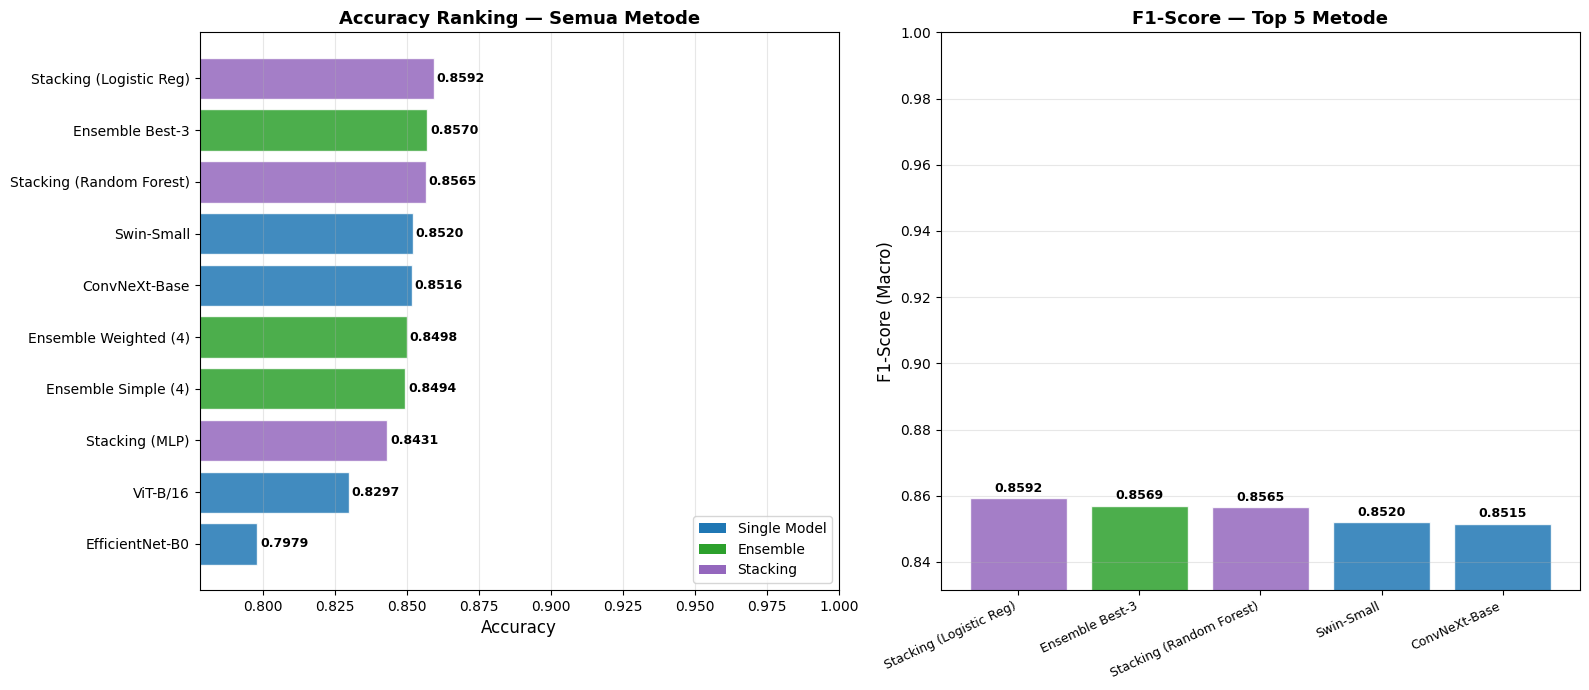

In [55]:
# ========================================
# CELL 28: Visualisasi Perbandingan Final
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Plot 1: Accuracy semua metode ─────────────────────────────────────────────
models_plot = ranked_df['Model'].tolist()
accs_plot   = ranked_df['Accuracy'].tolist()

color_map = []
for m in models_plot:
    if 'Stacking' in m:
        color_map.append('#9467bd')   # ungu untuk stacking
    elif 'Ensemble' in m:
        color_map.append('#2ca02c')   # hijau untuk ensemble
    else:
        color_map.append('#1f77b4')   # biru untuk single model

bars = axes[0].barh(models_plot[::-1], accs_plot[::-1],
                    color=color_map[::-1], alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy Ranking — Semua Metode', fontsize=13, fontweight='bold')
axes[0].set_xlim(min(accs_plot) - 0.02, 1.0)
axes[0].grid(True, alpha=0.3, axis='x')
for bar, v in zip(bars, accs_plot[::-1]):
    axes[0].text(v + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f77b4', label='Single Model'),
    Patch(facecolor='#2ca02c', label='Ensemble'),
    Patch(facecolor='#9467bd', label='Stacking'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=10)

# ── Plot 2: Radar chart F1 per kategori (jika humanitarian) ───────────────────
# Untuk binary: bar chart F1 tiap metode terbaik
top5 = ranked_df.head(5)
x    = np.arange(len(top5))
axes[1].bar(x, top5['F1-Score'], color=color_map[:5], alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top5['Model'], rotation=25, ha='right', fontsize=9)
axes[1].set_ylabel('F1-Score (Macro)', fontsize=12)
axes[1].set_title('F1-Score — Top 5 Metode', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(min(top5['F1-Score']) - 0.02, 1.0)
for i, (_, row) in enumerate(top5.iterrows()):
    axes[1].text(i, row['F1-Score'] + 0.002, f"{row['F1-Score']:.4f}",
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'final_comparison_v3.png'), dpi=300, bbox_inches='tight')
plt.show()

In [57]:
# ========================================
# CELL 29: Kesimpulan & Rekomendasi
# ========================================

best_row      = ranked_df.iloc[0]
baseline_acc  = full_results_df[full_results_df['Model'] == 'EfficientNet-B0']['Accuracy'].values[0]
best_stack    = full_results_df[full_results_df['Model'].str.contains('Stacking')]\
    .sort_values('Accuracy', ascending=False).iloc[0]
best_ensemble = full_results_df[full_results_df['Model'].str.contains('Ensemble')]\
    .sort_values('Accuracy', ascending=False).iloc[0]

print("\n" + "="*70)
print("KESIMPULAN AKHIR")
print("="*70)

print(f"\n🏆 Best Overall  : {best_row['Model']} — Acc={best_row['Accuracy']:.4f}")
print(f"🥇 Best Stacking : {best_stack['Model']} — Acc={best_stack['Accuracy']:.4f}")
print(f"🥈 Best Ensemble : {best_ensemble['Model']} — Acc={best_ensemble['Accuracy']:.4f}")
print(f"📌 Baseline      : EfficientNet-B0 — Acc={baseline_acc:.4f}")

print(f"\n📈 Gain vs Baseline:")
for _, row in ranked_df.iterrows():
    gain = row['Accuracy'] - baseline_acc
    sign = '+' if gain >= 0 else ''
    tag  = ''
    if 'Stacking' in row['Model']:  tag = '← Stacking'
    elif 'Ensemble' in row['Model']: tag = '← Ensemble'
    print(f"   {row['Model']:<35} {sign}{gain*100:.2f}%  {tag}")

print(f"\n💡 Rekomendasi Penggunaan:")
print(f"   • Real-time deployment → EfficientNet-B0 (tercepat)")
print(f"   • Offline/batch analysis → {best_row['Model']} (terbaik)")
print(f"   • Trade-off terbaik → {best_ensemble['Model']}")

# Save JSON final
final_results = {
    'task': TASK,
    'num_classes': NUM_CLASSES,
    'best_model': best_row['Model'],
    'best_accuracy': float(best_row['Accuracy']),
    'all_methods': {}
}
for _, row in full_results_df.iterrows():
    final_results['all_methods'][row['Model']] = {
        k: (float(v) if v is not None and not pd.isna(v) else None)
        for k, v in row.items() if k != 'Model'
    }
with open(os.path.join(RESULTS_DIR, 'all_results_v3.json'), 'w') as f:
    json.dump(final_results, f, indent=2)

print(f"\n✅ Semua hasil disimpan di: {RESULTS_DIR}")
print("="*70)


KESIMPULAN AKHIR

🏆 Best Overall  : Stacking (Logistic Reg) — Acc=0.8592
🥇 Best Stacking : Stacking (Logistic Reg) — Acc=0.8592
🥈 Best Ensemble : Ensemble Best-3 — Acc=0.8570
📌 Baseline      : EfficientNet-B0 — Acc=0.7979

📈 Gain vs Baseline:
   Stacking (Logistic Reg)             +6.12%  ← Stacking
   Ensemble Best-3                     +5.90%  ← Ensemble
   Stacking (Random Forest)            +5.86%  ← Stacking
   Swin-Small                          +5.41%  
   ConvNeXt-Base                       +5.36%  
   Ensemble Weighted (4)               +5.19%  ← Ensemble
   Ensemble Simple (4)                 +5.14%  ← Ensemble
   Stacking (MLP)                      +4.51%  ← Stacking
   ViT-B/16                            +3.17%  
   EfficientNet-B0                     +0.00%  

💡 Rekomendasi Penggunaan:
   • Real-time deployment → EfficientNet-B0 (tercepat)
   • Offline/batch analysis → Stacking (Logistic Reg) (terbaik)
   • Trade-off terbaik → Ensemble Best-3

✅ Semua hasil disimpan di: /